<a href="https://colab.research.google.com/github/ammarbadri919-tech/gnss-signal-state-prediction/blob/main/Copy%20_of_main_modeling_ipynb%20v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:


import zipfile

zip_path = "/content/drive/MyDrive/Gnns_kaggle_2324/smartphone-decimeter-2023.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()


print("Total files:", len(files))
print("\n".join(files[:50]))

Total files: 904
sdc2023/metadata/accumulated_delta_range_state_bit_map.json
sdc2023/metadata/constellation_type_mapping.csv
sdc2023/metadata/raw_state_bit_map.json
sdc2023/sample_submission.csv
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_imu.csv
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/supplemental/gnss_log.txt
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_gnss.csv
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_imu.csv
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/supplemental/gnss_log.txt
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_gnss.csv
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_imu.csv
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/supplemental/gnss_log.txt
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_gnss.csv
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_imu.csv
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/sup

In [62]:
csv_file = [file for file in files if file.endswith(".csv")]
print("CSV FILE FOUND",len(csv_file))
print("\n".join(csv_file[:50]))

CSV FILE FOUND 550
sdc2023/metadata/constellation_type_mapping.csv
sdc2023/sample_submission.csv
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_imu.csv
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_gnss.csv
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_imu.csv
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_gnss.csv
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_imu.csv
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_gnss.csv
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_imu.csv
sdc2023/test/2021-09-20-19-03-us-ca-mtv-l/pixel4/device_gnss.csv
sdc2023/test/2021-09-20-19-03-us-ca-mtv-l/pixel4/device_imu.csv
sdc2023/test/2021-09-28-21-56-us-ca-mtv-a/mi8/device_gnss.csv
sdc2023/test/2021-09-28-21-56-us-ca-mtv-a/mi8/device_imu.csv
sdc2023/test/2021-11-05-18-28-us-ca-mtv-m/pixel6pro/device_gnss.csv
sdc2023/test/2021-11-05-18-28-us-ca-mtv-m/pixel6pro/device_

In [63]:
gnss_files =[file for file in csv_file
             if file.endswith("/device_gnss.csv")]
print("GNSS files found",len(gnss_files))
print("\n".join(gnss_files[:50]))

GNSS files found 196
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_gnss.csv
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_gnss.csv
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_gnss.csv
sdc2023/test/2021-09-20-19-03-us-ca-mtv-l/pixel4/device_gnss.csv
sdc2023/test/2021-09-28-21-56-us-ca-mtv-a/mi8/device_gnss.csv
sdc2023/test/2021-11-05-18-28-us-ca-mtv-m/pixel6pro/device_gnss.csv
sdc2023/test/2021-11-30-20-59-us-ca-mtv-m/mi8/device_gnss.csv
sdc2023/test/2022-02-08-22-04-us-ca-sjc-r/pixel5/device_gnss.csv
sdc2023/test/2022-02-23-17-46-us-ca-lax-n/pixel5/device_gnss.csv
sdc2023/test/2022-02-23-22-35-us-ca-lax-m/pixel5/device_gnss.csv
sdc2023/test/2022-02-24-15-10-us-ca-lax-p/pixel5/device_gnss.csv
sdc2023/test/2022-02-24-22-14-us-ca-lax-i/pixel5/device_gnss.csv
sdc2023/test/2022-03-14-19-57-us-ca-mtv-pe1/xiaomimi8/device_gnss.csv
sdc2023/test/2022-03-17-20-16-us-ca-sjc-q/sm-g988b/device_gnss.

In [64]:
import pandas as pd
import zipfile
sample_file = gnss_files[0]
with zipfile.ZipFile(zip_path, "r") as z:
   sample_df = pd.read_csv(z.open(sample_file), nrows=5)
print("Sample file:", sample_file)
print("Columns:", len(sample_df.columns))
display(sample_df.head())


Sample file: sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
Columns: 58


,MessageType,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,...,SvVelocityYEcefMetersPerSecond,SvVelocityZEcefMetersPerSecond,SvClockBiasMeters,SvClockDriftMetersPerSecond,IsrbMeters,IonosphericDelayMeters,TroposphericDelayMeters,WlsPositionXEcefMeters,WlsPositionYEcefMeters,WlsPositionZEcefMeters
0,Raw,1607715055442,74585173000000,18,NaN,-1291675688269432104,-0.766369,22.548105,230.194956,9.674811,...,-340.093293,-3183.605736,238953.664854,-0.000900,0.0,3.359449,3.872354,-2.710175e+06,-4.278810e+06,3.863761e+06
1,Raw,1607715055442,74585173000000,18,NaN,-1291675688269432104,-0.766369,22.548105,230.194956,9.674811,...,-2609.046389,-1041.838400,-8170.672094,-0.003174,0.0,2.412421,2.769697,-2.710175e+06,-4.278810e+06,3.863761e+06
2,Raw,1607715055442,74585173000000,18,NaN,-1291675688269432104,-0.766369,22.548105,230.194956,9.674811,...,-948.201121,2096.337128,-48995.470518,-0.000954,0.0,3.041131,3.626980,-2.710175e+06,-4.278810e+06,3.863761e+06
3,Raw,1607715055442,74585173000000,18,NaN,-1291675688269432104,-0.766369,22.548105,230.194956,9.674811,...,-616.523320,3010.480790,-90005.243128,-0.001351,0.0,5.619127,15.589435,-2.710175e+06,-4.278810e+06,3.863761e+06
4,Raw,1607715055442,74585173000000,18,NaN,-1291675688269432104,-0.766369,22.548105,230.194956,9.674811,...,-936.390309,3013.610651,-74629.512567,-0.002282,0.0,6.382237,10.248850,-2.710175e+06,-4.278810e+06,3.863761e+06


In [65]:
import zipfile
with zipfile.ZipFile(zip_path, "r") as z:

  for file in gnss_files:
    print("Processing ",file)
    df =pd.read_csv(z.open(file))
    print("shape",df.shape)
    break


Processing  sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
shape (44501, 58)


In [66]:
import zipfile
with zipfile.ZipFile(zip_path, "r") as z:

  for file in gnss_files:
    print("Processing ",file)
    df =pd.read_csv(z.open(file))
    print("shape",df.shape)
    print("Memory used:",df.memory_usage(deep=True).sum() / 1024**2,
              "MB")
    break

Processing  sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
shape (44501, 58)
Memory used: 23.67861270904541 MB


In [67]:
print("Memory used",df.memory_usage(deep=True).sum() / 1024**2)
print(df.columns.tolist())


Memory used 23.67861270904541
['MessageType', 'utcTimeMillis', 'TimeNanos', 'LeapSecond', 'TimeUncertaintyNanos', 'FullBiasNanos', 'BiasNanos', 'BiasUncertaintyNanos', 'DriftNanosPerSecond', 'DriftUncertaintyNanosPerSecond', 'HardwareClockDiscontinuityCount', 'Svid', 'TimeOffsetNanos', 'State', 'ReceivedSvTimeNanos', 'ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'CarrierFrequencyHz', 'CarrierCycles', 'CarrierPhase', 'CarrierPhaseUncertainty', 'MultipathIndicator', 'SnrInDb', 'ConstellationType', 'AgcDb', 'BasebandCn0DbHz', 'FullInterSignalBiasNanos', 'FullInterSignalBiasUncertaintyNanos', 'SatelliteInterSignalBiasNanos', 'SatelliteInterSignalBiasUncertaintyNanos', 'CodeType', 'ChipsetElapsedRealtimeNanos', 'ArrivalTimeNanosSinceGpsEpoch', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'SignalType

In [68]:
features = [
    "ConstellationType",
    "Svid",
    "SignalType",
    "utcTimeMillis",
    "Cn0DbHz",
    "RawPseudorangeMeters",
    "PseudorangeRateMetersPerSecond",
    "AccumulatedDeltaRangeMeters",
    "SvElevationDegrees",
    "SvAzimuthDegrees"
]
df = df[features].copy()

print("new shape:", df.shape)

new shape: (44501, 10)


In [69]:

##df =df.sort_values(["Svid","utcTimeMillis"]).reset_index(drop=True)

In [70]:
df["signal_id"] = (
    df["ConstellationType"].astype(str)
    + "_"
    + df["Svid"].astype(str)
    + "_"
    + df["SignalType"].astype(str)
)

print(
    df[
        ["ConstellationType", "Svid", "SignalType", "signal_id"]
    ].head(10)
)

   ConstellationType  Svid SignalType       signal_id
0                  1     1  GPS_L1_CA   1_1_GPS_L1_CA
1                  1     3  GPS_L1_CA   1_3_GPS_L1_CA
2                  1     4  GPS_L1_CA   1_4_GPS_L1_CA
3                  1     9  GPS_L1_CA   1_9_GPS_L1_CA
4                  1    16  GPS_L1_CA  1_16_GPS_L1_CA
5                  1    21  GPS_L1_CA  1_21_GPS_L1_CA
6                  1    22  GPS_L1_CA  1_22_GPS_L1_CA
7                  1    31  GPS_L1_CA  1_31_GPS_L1_CA
8                  1    32  GPS_L1_CA  1_32_GPS_L1_CA
9                  3    10  GLO_G1_CA  3_10_GLO_G1_CA


In [71]:
df = df.sort_values(["signal_id","utcTimeMillis"]).reset_index(drop=True)
print(df[["signal_id","utcTimeMillis"]].head(20))

         signal_id  utcTimeMillis
0   1_16_GPS_L1_CA  1607715055442
1   1_16_GPS_L1_CA  1607715056442
2   1_16_GPS_L1_CA  1607715057442
3   1_16_GPS_L1_CA  1607715058442
4   1_16_GPS_L1_CA  1607715059442
5   1_16_GPS_L1_CA  1607715060442
6   1_16_GPS_L1_CA  1607715061442
7   1_16_GPS_L1_CA  1607715062442
8   1_16_GPS_L1_CA  1607715063442
9   1_16_GPS_L1_CA  1607715064442
10  1_16_GPS_L1_CA  1607715065442
11  1_16_GPS_L1_CA  1607715066442
12  1_16_GPS_L1_CA  1607715067442
13  1_16_GPS_L1_CA  1607715068442
14  1_16_GPS_L1_CA  1607715069442
15  1_16_GPS_L1_CA  1607715070442
16  1_16_GPS_L1_CA  1607715071442
17  1_16_GPS_L1_CA  1607715072442
18  1_16_GPS_L1_CA  1607715073442
19  1_16_GPS_L1_CA  1607715074442


In [72]:
numerica_cols =[ "Cn0DbHz",
    "RawPseudorangeMeters",
    "PseudorangeRateMetersPerSecond",
    "AccumulatedDeltaRangeMeters",
    "SvElevationDegrees",
    "SvAzimuthDegrees"
]


In [73]:
df[numerica_cols]=(df.groupby("signal_id")[numerica_cols].transform( lambda x: x.interpolate(
              method="linear",
              limit=2,
              limit_direction="both")))


In [74]:
df = df.dropna(subset= numerica_cols).reset_index(drop=True)

print("new shape:", df.shape)
print("Remaining NaNs:")
print(df[numerica_cols].isna().sum())

new shape: (44276, 11)
Remaining NaNs:
Cn0DbHz                           0
RawPseudorangeMeters              0
PseudorangeRateMetersPerSecond    0
AccumulatedDeltaRangeMeters       0
SvElevationDegrees                0
SvAzimuthDegrees                  0
dtype: int64


Cn0DbHz = signal strength.

In [75]:
def circular_diff_group(group):
    group = group.copy()
    group["Azimuth_change"] = (
        (group["SvAzimuthDegrees"].diff() + 180) % 360
    ) - 180
    return group

df = (
    df.groupby("signal_id", group_keys=False)
      .apply(circular_diff_group)
      .reset_index(drop=True)
)

df["Azimuth_change"] = df["Azimuth_change"].clip(-180, 180)
print("Azimuth circular diff applied successfully!")

Azimuth circular diff applied successfully!


/tmp/ipykernel_3457/4088929506.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(circular_diff_group)


In [76]:
df["Cn0_change"]=(df.groupby("signal_id")["Cn0DbHz"].diff())


In [77]:
#C/N0 rolling mean
df["Cn0_rolling_mean"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).mean()
      )
)

In [78]:
df["Cn0_trend_mean"]=df.groupby("signal_id")["Cn0_change"].transform(lambda x: x.rolling(window=3,min_periods=1).mean())
print("Cn0_trend_mean")


Cn0_trend_mean


In [79]:
df["is_up"]= df["Cn0_trend_mean"]>0
print("is_up")

is_up


In [80]:
df["up_streak"] = (
    df.groupby("signal_id")["is_up"]
      .transform(
          lambda x:
              x.astype(int)
               .groupby((x != x.shift()).cumsum())
               .cumsum()
      )
)

print("up_streak created")

up_streak created


In [81]:
df["is_down"]= df["Cn0_trend_mean"]<0
print("is_down")

is_down


In [82]:
df["down_streak"] = (
    df.groupby("signal_id")["is_down"]
      .transform(
          lambda x:
              x.astype(int)
               .groupby((x != x.shift()).cumsum())
               .cumsum()
      )
)

print("down_streak created")

down_streak created


In [83]:
df["Cn0_rolling_std"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).mean()
      )
)

In [84]:
display( df[ [ "signal_id", "Cn0DbHz", "Cn0_rolling_std" ] ].head(15) )

,signal_id,Cn0DbHz,Cn0_rolling_std
0,1_16_GPS_L1_CA,36.4,36.400000
1,1_16_GPS_L1_CA,36.6,36.500000
2,1_16_GPS_L1_CA,36.1,36.366667
3,1_16_GPS_L1_CA,38.2,36.825000
4,1_16_GPS_L1_CA,39.5,37.360000
5,1_16_GPS_L1_CA,38.9,37.860000
6,1_16_GPS_L1_CA,40.0,38.540000
7,1_16_GPS_L1_CA,38.5,39.020000
8,1_16_GPS_L1_CA,35.1,38.400000
9,1_16_GPS_L1_CA,41.4,38.780000


In [85]:
df['cn0_slope']=(df.groupby("signal_id")["Cn0DbHz"].transform(lambda x: x. diff(4)/4))
print("cn0_slope")

cn0_slope


In [86]:
display( df[ [ "signal_id", "Cn0DbHz", "cn0_slope" ] ].head(15) )

,signal_id,Cn0DbHz,cn0_slope
0,1_16_GPS_L1_CA,36.4,NaN
1,1_16_GPS_L1_CA,36.6,NaN
2,1_16_GPS_L1_CA,36.1,NaN
3,1_16_GPS_L1_CA,38.2,NaN
4,1_16_GPS_L1_CA,39.5,0.775
5,1_16_GPS_L1_CA,38.9,0.575
6,1_16_GPS_L1_CA,40.0,0.975
7,1_16_GPS_L1_CA,38.5,0.075
8,1_16_GPS_L1_CA,35.1,-1.100
9,1_16_GPS_L1_CA,41.4,0.625


df["Cn0_acceleration"] = (
    df.groupby("signal_id")["Cn0_slope"]
      .diff()
)

print("Cn0_acceleration created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_slope",
            "Cn0_acceleration"
        ]
    ].head(15)
)

In [88]:
print(df[["signal_id","utcTimeMillis", "Cn0DbHz" , "Cn0_change"]].head(20))

         signal_id  utcTimeMillis  Cn0DbHz  Cn0_change
0   1_16_GPS_L1_CA  1607715055442     36.4         NaN
1   1_16_GPS_L1_CA  1607715056442     36.6         0.2
2   1_16_GPS_L1_CA  1607715057442     36.1        -0.5
3   1_16_GPS_L1_CA  1607715058442     38.2         2.1
4   1_16_GPS_L1_CA  1607715059442     39.5         1.3
5   1_16_GPS_L1_CA  1607715060442     38.9        -0.6
6   1_16_GPS_L1_CA  1607715061442     40.0         1.1
7   1_16_GPS_L1_CA  1607715062442     38.5        -1.5
8   1_16_GPS_L1_CA  1607715063442     35.1        -3.4
9   1_16_GPS_L1_CA  1607715064442     41.4         6.3
10  1_16_GPS_L1_CA  1607715065442     43.6         2.2
11  1_16_GPS_L1_CA  1607715066442     40.2        -3.4
12  1_16_GPS_L1_CA  1607715067442     41.2         1.0
13  1_16_GPS_L1_CA  1607715068442     41.5         0.3
14  1_16_GPS_L1_CA  1607715069442     41.4        -0.1
15  1_16_GPS_L1_CA  1607715070442     40.8        -0.6
16  1_16_GPS_L1_CA  1607715071442     38.7        -2.1
17  1_16_G

In [89]:
df["time_gap"] = (
    df.groupby("signal_id")["utcTimeMillis"].diff()
)

print(
    df[
        ["signal_id", "utcTimeMillis", "time_gap"]
    ].head(20)
)

         signal_id  utcTimeMillis  time_gap
0   1_16_GPS_L1_CA  1607715055442       NaN
1   1_16_GPS_L1_CA  1607715056442    1000.0
2   1_16_GPS_L1_CA  1607715057442    1000.0
3   1_16_GPS_L1_CA  1607715058442    1000.0
4   1_16_GPS_L1_CA  1607715059442    1000.0
5   1_16_GPS_L1_CA  1607715060442    1000.0
6   1_16_GPS_L1_CA  1607715061442    1000.0
7   1_16_GPS_L1_CA  1607715062442    1000.0
8   1_16_GPS_L1_CA  1607715063442    1000.0
9   1_16_GPS_L1_CA  1607715064442    1000.0
10  1_16_GPS_L1_CA  1607715065442    1000.0
11  1_16_GPS_L1_CA  1607715066442    1000.0
12  1_16_GPS_L1_CA  1607715067442    1000.0
13  1_16_GPS_L1_CA  1607715068442    1000.0
14  1_16_GPS_L1_CA  1607715069442    1000.0
15  1_16_GPS_L1_CA  1607715070442    1000.0
16  1_16_GPS_L1_CA  1607715071442    1000.0
17  1_16_GPS_L1_CA  1607715072442    1000.0
18  1_16_GPS_L1_CA  1607715073442    1000.0
19  1_16_GPS_L1_CA  1607715074442    1000.0


In [90]:
df["Pseudorange_change"]=(df.groupby("signal_id")["RawPseudorangeMeters"].diff())
print(
    df[
        ["signal_id", "utcTimeMillis","RawPseudorangeMeters","Pseudorange_change"]
    ].head(20)
)

         signal_id  utcTimeMillis  RawPseudorangeMeters  Pseudorange_change
0   1_16_GPS_L1_CA  1607715055442          2.418345e+07                 NaN
1   1_16_GPS_L1_CA  1607715056442          2.418287e+07         -579.199029
2   1_16_GPS_L1_CA  1607715057442          2.418229e+07         -573.802765
3   1_16_GPS_L1_CA  1607715058442          2.418172e+07         -568.706293
4   1_16_GPS_L1_CA  1607715059442          2.418116e+07         -568.406500
5   1_16_GPS_L1_CA  1607715060442          2.418058e+07         -578.599444
6   1_16_GPS_L1_CA  1607715061442          2.418001e+07         -571.704217
7   1_16_GPS_L1_CA  1607715062442          2.417943e+07         -572.603595
8   1_16_GPS_L1_CA  1607715063442          2.417885e+07         -580.997784
9   1_16_GPS_L1_CA  1607715064442          2.417827e+07         -576.800689
10  1_16_GPS_L1_CA  1607715065442          2.417770e+07         -578.899236
11  1_16_GPS_L1_CA  1607715066442          2.417712e+07         -577.100482
12  1_16_GPS

In [91]:
df["PseudorangeRate_change"]=(df.groupby("signal_id")["PseudorangeRateMetersPerSecond"].diff())


In [92]:
df["Elevation_change"] = (
    df.groupby("signal_id")["SvElevationDegrees"].diff()
)

print(
    df[
        [
            "signal_id",
            "utcTimeMillis",
            "SvElevationDegrees",
            "Elevation_change"
        ]
    ].head(20)
)

         signal_id  utcTimeMillis  SvElevationDegrees  Elevation_change
0   1_16_GPS_L1_CA  1607715055442           13.900605               NaN
1   1_16_GPS_L1_CA  1607715056442           13.906558          0.005952
2   1_16_GPS_L1_CA  1607715057442           13.912509          0.005952
3   1_16_GPS_L1_CA  1607715058442           13.918452          0.005943
4   1_16_GPS_L1_CA  1607715059442           13.924405          0.005953
5   1_16_GPS_L1_CA  1607715060442           13.930350          0.005946
6   1_16_GPS_L1_CA  1607715061442           13.936303          0.005952
7   1_16_GPS_L1_CA  1607715062442           13.942265          0.005962
8   1_16_GPS_L1_CA  1607715063442           13.948238          0.005973
9   1_16_GPS_L1_CA  1607715064442           13.954199          0.005961
10  1_16_GPS_L1_CA  1607715065442           13.960156          0.005957
11  1_16_GPS_L1_CA  1607715066442           13.966096          0.005940
12  1_16_GPS_L1_CA  1607715067442           13.972024          0

In [113]:
df["Azimuth_change"] = (
    df.groupby("signal_id")["SvAzimuthDegrees"].diff()
)

print(
    df[
        [
            "signal_id",
            "utcTimeMillis",
            "SvAzimuthDegrees",
            "Azimuth_change"
        ]
    ].head(20)
)

ValueError: Columns must be same length as key

In [114]:
print(df["Azimuth_change"].describe())

count    44233.000000
mean        -0.002650
std          0.016816
min         -0.652393
25%         -0.006347
50%         -0.004016
75%          0.005328
max          0.811208
Name: Azimuth_change, dtype: float64


In [94]:
print(
    df[
        [
            "Cn0_change",
            "time_gap",
            "Pseudorange_change",
            "PseudorangeRate_change",
            "Elevation_change",
            "Azimuth_change"
        ]
    ].isna().sum()
)

Cn0_change                43
time_gap                  43
Pseudorange_change        43
PseudorangeRate_change    43
Elevation_change          43
Azimuth_change            43
dtype: int64


In [95]:
print(df["Cn0DbHz"].describe())

count    44276.000000
mean        35.110518
std          5.912629
min         20.000000
25%         31.000000
50%         35.700000
75%         39.600000
max         48.800000
Name: Cn0DbHz, dtype: float64


In [96]:
print(
    df[
        ["signal_id", "utcTimeMillis", "Cn0DbHz", "Cn0_change"]
    ]
    .sort_values("Cn0DbHz")
    .head(20)
)

             signal_id  utcTimeMillis  Cn0DbHz  Cn0_change
34124   6_26_GAL_E5A_Q  1607715182442     20.0        -1.3
16664     1_9_GPS_L5_Q  1607715493442     20.0        -2.6
32364   6_21_GAL_E5A_Q  1607715543442     20.0        -5.3
14256    1_6_GPS_L1_CA  1607715097442     20.0         NaN
28047   6_12_GAL_E5A_Q  1607715382442     20.0        -0.9
3722    1_21_GPS_L1_CA  1607715333442     20.0       -14.6
793     1_16_GPS_L1_CA  1607715909442     20.0        -0.5
7667     1_26_GPS_L5_Q  1607715835442     20.1        -4.9
4220    1_21_GPS_L1_CA  1607715838442     20.1        -1.0
13736     1_4_GPS_L5_Q  1607715692442     20.1        -2.2
16884     1_9_GPS_L5_Q  1607715763442     20.1        -9.2
21342   3_23_GLO_G1_CA  1607715624442     20.1        -4.4
32383   6_21_GAL_E5A_Q  1607715573442     20.1        -2.7
2702      1_1_GPS_L5_Q  1607715497442     20.1        -1.3
22312   3_24_GLO_G1_CA  1607715437442     20.1        -4.1
36319   6_27_GAL_E5A_Q  1607715250442     20.1        -1

In [97]:
signal = "1_21_GPS_L1_CA"

print(
    df[df["signal_id"] == signal][
        ["utcTimeMillis", "Cn0DbHz", "Cn0_change"]
    ].head(30)
)

      utcTimeMillis  Cn0DbHz  Cn0_change
3447  1607715055442     26.8         NaN
3448  1607715056442     29.0         2.2
3449  1607715057442     29.2         0.2
3450  1607715058442     29.8         0.6
3451  1607715059442     32.4         2.6
3452  1607715060442     27.9        -4.5
3453  1607715061442     33.5         5.6
3454  1607715062442     39.2         5.7
3455  1607715063442     41.9         2.7
3456  1607715064442     44.0         2.1
3457  1607715065442     37.6        -6.4
3458  1607715066442     32.4        -5.2
3459  1607715067442     32.3        -0.1
3460  1607715068442     31.6        -0.7
3461  1607715069442     28.5        -3.1
3462  1607715070442     25.4        -3.1
3463  1607715071442     27.6         2.2
3464  1607715072442     33.5         5.9
3465  1607715073442     30.6        -2.9
3466  1607715074442     37.9         7.3
3467  1607715075442     40.6         2.7
3468  1607715076442     40.5        -0.1
3469  1607715077442     42.3         1.8
3470  1607715078

In [98]:
df['Cn0_rolling_mean'] = df.groupby('signal_id')['Cn0DbHz'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

In [99]:
# ============================================================
# EXISTING TEMPORAL FEATURES
# ============================================================

# 1. C/N0 Rolling Mean
df["Cn0_rolling_mean"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).std()
      )
)

# 2. C/N0 Trend
# Current C/N0 - C/N0 from 4 observations ago
df["Cn0_trend"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.diff(4)
      )
)

# 3. C/N0 Trend Mean
# Average of recent 3 C/N0 changes
df["Cn0_trend_mean"] = (
    df.groupby("signal_id")["Cn0_change"]
      .transform(
          lambda x: x.rolling(
              window=3,
              min_periods=1
          ).mean()
      )
)

# 4. Is the signal going UP?
df["is_up"] = (
    df["Cn0_trend_mean"] > 0
)

# 5. Consecutive UP observations
df["up_streak"] = (
    df.groupby("signal_id")["is_up"]
      .transform(
          lambda x:
              x.astype(int)
               .groupby((x != x.shift()).cumsum())
               .cumsum()
      )
)

# 6. Is the signal going DOWN?
df["is_down"] = (
    df["Cn0_trend_mean"] < 0
)

# 7. Consecutive DOWN observations
df["down_streak"] = (
    df.groupby("signal_id")["is_down"]
      .transform(
          lambda x:
              x.astype(int)
               .groupby((x != x.shift()).cumsum())
               .cumsum()
      )
)

print("All existing temporal features created successfully.")

All existing temporal features created successfully.


In [100]:
display(
    df[
        ["signal_id", "Cn0DbHz", "Cn0_rolling_std"]
    ].head(15)
)

,signal_id,Cn0DbHz,Cn0_rolling_std
0,1_16_GPS_L1_CA,36.4,36.400000
1,1_16_GPS_L1_CA,36.6,36.500000
2,1_16_GPS_L1_CA,36.1,36.366667
3,1_16_GPS_L1_CA,38.2,36.825000
4,1_16_GPS_L1_CA,39.5,37.360000
5,1_16_GPS_L1_CA,38.9,37.860000
6,1_16_GPS_L1_CA,40.0,38.540000
7,1_16_GPS_L1_CA,38.5,39.020000
8,1_16_GPS_L1_CA,35.1,38.400000
9,1_16_GPS_L1_CA,41.4,38.780000


In [103]:
# C/N0 Slope
df["Cn0_slope"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(lambda x: x.diff(4) / 4)
)

# C/N0 Acceleration
df["Cn0_acceleration"] = (
    df.groupby("signal_id")["Cn0_slope"]
      .diff()
)

print("Cn0_slope created:", "Cn0_slope" in df.columns)
print("Cn0_acceleration created:", "Cn0_acceleration" in df.columns)

Cn0_slope created: True
Cn0_acceleration created: True


KeyError: 'Column not found: Cn0_slope'

In [104]:
df["Cn0_trend"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(lambda x: x.diff(4))
)

print("Cn0_trend created")

Cn0_trend created


In [105]:
# Feature 4: Minimum C/N0 in recent 5 observations

df["Cn0_min_5"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).min()
      )
)

print("Cn0_min_5 created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_min_5"
        ]
    ].head(15)
)

Cn0_min_5 created


,signal_id,Cn0DbHz,Cn0_min_5
0,1_16_GPS_L1_CA,36.4,36.4
1,1_16_GPS_L1_CA,36.6,36.4
2,1_16_GPS_L1_CA,36.1,36.1
3,1_16_GPS_L1_CA,38.2,36.1
4,1_16_GPS_L1_CA,39.5,36.1
5,1_16_GPS_L1_CA,38.9,36.1
6,1_16_GPS_L1_CA,40.0,36.1
7,1_16_GPS_L1_CA,38.5,38.2
8,1_16_GPS_L1_CA,35.1,35.1
9,1_16_GPS_L1_CA,41.4,35.1


In [106]:
# Feature 5: Maximum C/N0 in recent 5 observations

df["Cn0_max_5"] = (
    df.groupby("signal_id")["Cn0DbHz"]
      .transform(
          lambda x: x.rolling(
              window=5,
              min_periods=1
          ).max()
      )
)

print("Cn0_max_5 created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_min_5",
            "Cn0_max_5"
        ]
    ].head(15)
)

Cn0_max_5 created


,signal_id,Cn0DbHz,Cn0_min_5,Cn0_max_5
0,1_16_GPS_L1_CA,36.4,36.4,36.4
1,1_16_GPS_L1_CA,36.6,36.4,36.6
2,1_16_GPS_L1_CA,36.1,36.1,36.6
3,1_16_GPS_L1_CA,38.2,36.1,38.2
4,1_16_GPS_L1_CA,39.5,36.1,39.5
5,1_16_GPS_L1_CA,38.9,36.1,39.5
6,1_16_GPS_L1_CA,40.0,36.1,40.0
7,1_16_GPS_L1_CA,38.5,38.2,40.0
8,1_16_GPS_L1_CA,35.1,35.1,40.0
9,1_16_GPS_L1_CA,41.4,35.1,41.4


In [107]:
# Feature 6: C/N0 range in recent 5 observations

df["Cn0_range_5"] = (
    df["Cn0_max_5"] - df["Cn0_min_5"]
)

print("Cn0_range_5 created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_min_5",
            "Cn0_max_5",
            "Cn0_range_5"
        ]
    ].head(15)
)

Cn0_range_5 created


,signal_id,Cn0DbHz,Cn0_min_5,Cn0_max_5,Cn0_range_5
0,1_16_GPS_L1_CA,36.4,36.4,36.4,0.0
1,1_16_GPS_L1_CA,36.6,36.4,36.6,0.2
2,1_16_GPS_L1_CA,36.1,36.1,36.6,0.5
3,1_16_GPS_L1_CA,38.2,36.1,38.2,2.1
4,1_16_GPS_L1_CA,39.5,36.1,39.5,3.4
5,1_16_GPS_L1_CA,38.9,36.1,39.5,3.4
6,1_16_GPS_L1_CA,40.0,36.1,40.0,3.9
7,1_16_GPS_L1_CA,38.5,38.2,40.0,1.8
8,1_16_GPS_L1_CA,35.1,35.1,40.0,4.9
9,1_16_GPS_L1_CA,41.4,35.1,41.4,6.3


In [108]:
# Feature 7: Number of C/N0 decreases in recent 10 observations

df["negative_change_count_10"] = (
    df.groupby("signal_id")["Cn0_change"]
      .transform(
          lambda x: (
              (x < 0)
              .rolling(
                  window=10,
                  min_periods=1
              )
              .sum()
          )
      )
)

print("negative_change_count_10 created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_change",
            "negative_change_count_10"
        ]
    ].head(15)
)

negative_change_count_10 created


,signal_id,Cn0DbHz,Cn0_change,negative_change_count_10
0,1_16_GPS_L1_CA,36.4,NaN,0.0
1,1_16_GPS_L1_CA,36.6,0.2,0.0
2,1_16_GPS_L1_CA,36.1,-0.5,1.0
3,1_16_GPS_L1_CA,38.2,2.1,1.0
4,1_16_GPS_L1_CA,39.5,1.3,1.0
5,1_16_GPS_L1_CA,38.9,-0.6,2.0
6,1_16_GPS_L1_CA,40.0,1.1,2.0
7,1_16_GPS_L1_CA,38.5,-1.5,3.0
8,1_16_GPS_L1_CA,35.1,-3.4,4.0
9,1_16_GPS_L1_CA,41.4,6.3,4.0


In [109]:
# Feature 8: Number of C/N0 increases in recent 10 observations

df["positive_change_count_10"] = (
    df.groupby("signal_id")["Cn0_change"]
      .transform(
          lambda x: (
              (x > 0)
              .rolling(
                  window=10,
                  min_periods=1
              )
              .sum()
          )
      )
)

print("positive_change_count_10 created")

display(
    df[
        [
            "signal_id",
            "Cn0DbHz",
            "Cn0_change",
            "positive_change_count_10"
        ]
    ].head(15)
)

positive_change_count_10 created


,signal_id,Cn0DbHz,Cn0_change,positive_change_count_10
0,1_16_GPS_L1_CA,36.4,NaN,0.0
1,1_16_GPS_L1_CA,36.6,0.2,1.0
2,1_16_GPS_L1_CA,36.1,-0.5,1.0
3,1_16_GPS_L1_CA,38.2,2.1,2.0
4,1_16_GPS_L1_CA,39.5,1.3,3.0
5,1_16_GPS_L1_CA,38.9,-0.6,3.0
6,1_16_GPS_L1_CA,40.0,1.1,4.0
7,1_16_GPS_L1_CA,38.5,-1.5,4.0
8,1_16_GPS_L1_CA,35.1,-3.4,4.0
9,1_16_GPS_L1_CA,41.4,6.3,5.0


In [110]:
input_features = [
    # Existing 12
    "Cn0DbHz",
    "Cn0_change",
    "Cn0_trend",
    "Cn0_trend_mean",
    "down_streak",
    "up_streak",
    "PseudorangeRateMetersPerSecond",
    "PseudorangeRate_change",
    "SvElevationDegrees",
    "Elevation_change",
    "SvAzimuthDegrees",
    "Azimuth_change",

    # New 8
    "Cn0_rolling_std",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10"
]

print("Total input features:", len(input_features))
print(input_features)

Total input features: 20
['Cn0DbHz', 'Cn0_change', 'Cn0_trend', 'Cn0_trend_mean', 'down_streak', 'up_streak', 'PseudorangeRateMetersPerSecond', 'PseudorangeRate_change', 'SvElevationDegrees', 'Elevation_change', 'SvAzimuthDegrees', 'Azimuth_change', 'Cn0_rolling_std', 'Cn0_slope', 'Cn0_acceleration', 'Cn0_min_5', 'Cn0_max_5', 'Cn0_range_5', 'negative_change_count_10', 'positive_change_count_10']


In [112]:
missing_fectures =[
    f for f in input_features
    if f not in df.columns

]
print("missing",missing_fectures)

missing []


In [120]:
print("NaN count in 20 input features:")
print(df[input_features].isna().sum())

print("\nTotal NaN values:")
print(df[input_features].isna().sum().sum())

NaN count in 20 input features:
Cn0DbHz                             0
Cn0_change                         43
Cn0_trend                         172
Cn0_trend_mean                     43
down_streak                         0
up_streak                           0
PseudorangeRateMetersPerSecond      0
PseudorangeRate_change             43
SvElevationDegrees                  0
Elevation_change                   43
SvAzimuthDegrees                    0
Azimuth_change                     43
Cn0_rolling_std                     0
Cn0_slope                         172
Cn0_acceleration                  215
Cn0_min_5                           0
Cn0_max_5                           0
Cn0_range_5                         0
negative_change_count_10            0
positive_change_count_10            0
dtype: int64

Total NaN values:
774


In [121]:
df = df.dropna(subset=input_features).reset_index(drop=True)

print("Shape after removing NaNs:", df.shape)

print("\nRemaining NaNs:")
print(df[input_features].isna().sum().sum())

Shape after removing NaNs: (44061, 33)

Remaining NaNs:
0


In [137]:
import os

corrected_dir = "/content/gnss_features_v2"
os.makedirs(corrected_dir, exist_ok=True)

print("Output folder:", corrected_dir)

Output folder: /content/gnss_features_v2


In [138]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Gnns_kaggle_2324/smartphone-decimeter-2023.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    gnss_files = [
        f for f in z.namelist()
        if f.endswith("/device_gnss.csv")
    ]

print("Total GNSS files found:", len(gnss_files))
print("First file:", gnss_files[0])
print("Last file:", gnss_files[-1])

Total GNSS files found: 196
First file: sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
Last file: sdc2023/train/2023-09-07-22-48-us-ca-routebc2/pixel5a/device_gnss.csv


In [139]:
# ============================================================
# REGENERATE ALL 196 FILES WITH CORRECTED 20 FEATURES
# ============================================================

import os
import zipfile
import pandas as pd
import numpy as np

zip_path = "/content/drive/MyDrive/Gnns_kaggle_2324/smartphone-decimeter-2023.zip"
corrected_dir = "/content/gnss_features_v2"

os.makedirs(corrected_dir, exist_ok=True)

# ------------------------------------------------------------
# 20 MODEL FEATURES
# ------------------------------------------------------------

input_features = [
    "Cn0DbHz",
    "Cn0_change",
    "Cn0_trend",
    "Cn0_trend_mean",
    "down_streak",
    "up_streak",
    "PseudorangeRateMetersPerSecond",
    "PseudorangeRate_change",
    "SvElevationDegrees",
    "Elevation_change",
    "SvAzimuthDegrees",
    "Azimuth_change",
    "Cn0_rolling_std",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10"
]

# ------------------------------------------------------------
# FIND ALL 196 GNSS FILES
# ------------------------------------------------------------

with zipfile.ZipFile(zip_path, "r") as z:

    gnss_files = sorted([
        f for f in z.namelist()
        if f.endswith("/device_gnss.csv")
    ])

print("Total GNSS files:", len(gnss_files))

assert len(gnss_files) == 196, \
    f"Expected 196 files, found {len(gnss_files)}"

# ------------------------------------------------------------
# PROCESS EACH FILE
# ------------------------------------------------------------

for idx, file_path in enumerate(gnss_files, start=1):

    print(f"\n[{idx}/196] Processing:")
    print(file_path)

    # --------------------------------------------------------
    # READ ONE FILE ONLY
    # --------------------------------------------------------

    with zipfile.ZipFile(zip_path, "r") as z:
        df = pd.read_csv(z.open(file_path))

    # --------------------------------------------------------
    # SELECT REQUIRED RAW FEATURES
    # --------------------------------------------------------

    raw_features = [
        "ConstellationType",
        "Svid",
        "SignalType",
        "utcTimeMillis",
        "Cn0DbHz",
        "RawPseudorangeMeters",
        "PseudorangeRateMetersPerSecond",
        "AccumulatedDeltaRangeMeters",
        "SvElevationDegrees",
        "SvAzimuthDegrees"
    ]

    df = df[raw_features].copy()

    # --------------------------------------------------------
    # CREATE SIGNAL ID
    # --------------------------------------------------------

    df["signal_id"] = (
        df["ConstellationType"].astype(str)
        + "_"
        + df["Svid"].astype(str)
        + "_"
        + df["SignalType"].astype(str)
    )

    # --------------------------------------------------------
    # SORT BY SIGNAL + TIME
    # --------------------------------------------------------

    df = df.sort_values(
        ["signal_id", "utcTimeMillis"]
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # INTERPOLATION
    # --------------------------------------------------------

    numeric_cols = [
        "Cn0DbHz",
        "RawPseudorangeMeters",
        "PseudorangeRateMetersPerSecond",
        "AccumulatedDeltaRangeMeters",
        "SvElevationDegrees",
        "SvAzimuthDegrees"
    ]

    df[numeric_cols] = (
        df.groupby("signal_id")[numeric_cols]
          .transform(
              lambda x: x.interpolate(
                  method="linear",
                  limit=2,
                  limit_direction="both"
              )
          )
    )

    df = df.dropna(
        subset=numeric_cols
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # C/N0 CHANGE
    # --------------------------------------------------------

    df["Cn0_change"] = (
        df.groupby("signal_id")["Cn0DbHz"].diff()
    )

    # --------------------------------------------------------
    # C/N0 ROLLING MEAN
    # --------------------------------------------------------

    df["Cn0_rolling_mean"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.rolling(
                  window=5,
                  min_periods=1
              ).mean()
          )
    )

    # --------------------------------------------------------
    # C/N0 TREND
    # --------------------------------------------------------

    df["Cn0_trend"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.diff(4)
          )
    )

    # --------------------------------------------------------
    # C/N0 TREND MEAN
    # --------------------------------------------------------

    df["Cn0_trend_mean"] = (
        df.groupby("signal_id")["Cn0_change"]
          .transform(
              lambda x: x.rolling(
                  window=3,
                  min_periods=1
              ).mean()
          )
    )

    # --------------------------------------------------------
    # UP / DOWN
    # --------------------------------------------------------

    df["is_up"] = (
        df["Cn0_trend_mean"] > 0
    )

    df["up_streak"] = (
        df.groupby("signal_id")["is_up"]
          .transform(
              lambda x:
                  x.astype(int)
                   .groupby((x != x.shift()).cumsum())
                   .cumsum()
          )
    )

    df["is_down"] = (
        df["Cn0_trend_mean"] < 0
    )

    df["down_streak"] = (
        df.groupby("signal_id")["is_down"]
          .transform(
              lambda x:
                  x.astype(int)
                   .groupby((x != x.shift()).cumsum())
                   .cumsum()
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 1: ROLLING STD
    # --------------------------------------------------------

    df["Cn0_rolling_std"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.rolling(
                  window=5,
                  min_periods=2
              ).std()
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 2: SLOPE
    # --------------------------------------------------------

    df["Cn0_slope"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.diff(4) / 4
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 3: ACCELERATION
    # --------------------------------------------------------

    df["Cn0_acceleration"] = (
        df.groupby("signal_id")["Cn0_slope"].diff()
    )

    # --------------------------------------------------------
    # TIME GAP
    # --------------------------------------------------------

    df["time_gap"] = (
        df.groupby("signal_id")["utcTimeMillis"].diff()
    )

    # --------------------------------------------------------
    # PSEUDORANGE CHANGE
    # --------------------------------------------------------

    df["Pseudorange_change"] = (
        df.groupby("signal_id")[
            "RawPseudorangeMeters"
        ].diff()
    )

    # --------------------------------------------------------
    # PSEUDORANGE RATE CHANGE
    # --------------------------------------------------------

    df["PseudorangeRate_change"] = (
        df.groupby("signal_id")[
            "PseudorangeRateMetersPerSecond"
        ].diff()
    )

    # --------------------------------------------------------
    # ELEVATION CHANGE
    # --------------------------------------------------------

    df["Elevation_change"] = (
        df.groupby("signal_id")[
            "SvElevationDegrees"
        ].diff()
    )

    # --------------------------------------------------------
    # CIRCULAR AZIMUTH CHANGE
    # --------------------------------------------------------

    df["Azimuth_change"] = (
        (
            df.groupby("signal_id")[
                "SvAzimuthDegrees"
            ].diff() + 180
        ) % 360
    ) - 180

    df["Azimuth_change"] = (
        df["Azimuth_change"].clip(-180, 180)
    )

    # --------------------------------------------------------
    # NEW FEATURE 4: MIN
    # --------------------------------------------------------

    df["Cn0_min_5"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.rolling(
                  window=5,
                  min_periods=1
              ).min()
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 5: MAX
    # --------------------------------------------------------

    df["Cn0_max_5"] = (
        df.groupby("signal_id")["Cn0DbHz"]
          .transform(
              lambda x: x.rolling(
                  window=5,
                  min_periods=1
              ).max()
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 6: RANGE
    # --------------------------------------------------------

    df["Cn0_range_5"] = (
        df["Cn0_max_5"] - df["Cn0_min_5"]
    )

    # --------------------------------------------------------
    # NEW FEATURE 7: NEGATIVE COUNT
    # --------------------------------------------------------

    df["negative_change_count_10"] = (
        df.groupby("signal_id")["Cn0_change"]
          .transform(
              lambda x:
                  (x < 0)
                  .rolling(
                      window=10,
                      min_periods=1
                  )
                  .sum()
          )
    )

    # --------------------------------------------------------
    # NEW FEATURE 8: POSITIVE COUNT
    # --------------------------------------------------------

    df["positive_change_count_10"] = (
        df.groupby("signal_id")["Cn0_change"]
          .transform(
              lambda x:
                  (x > 0)
                  .rolling(
                      window=10,
                      min_periods=1
                  )
                  .sum()
          )
    )

    # REMOVE ROWS WHERE 20 FEATURES ARE INCOMPLETE

    df = df.dropna(
        subset=input_features
    ).reset_index(drop=True)


    # VERIFY

    missing_features = [
        f for f in input_features
        if f not in df.columns
    ]

    assert not missing_features, \
        f"Missing features: {missing_features}"

    remaining_nan = (
        df[input_features]
        .isna()
        .sum()
        .sum()
    )

    assert remaining_nan == 0, \
        f"Remaining NaNs: {remaining_nan}"

    output_name = f"gnss_{idx:03d}.parquet"

    output_path = os.path.join(
        corrected_dir,
        output_name
    )

    df.to_parquet(
        output_path,
        index=False
    )

    print(
        f"Saved {output_name} | "
        f"Rows: {len(df)} | "
        f"Columns: {len(df.columns)}"
    )

print("\n========================================")
print("DONE — ALL 196 FILES PROCESSED")
print("========================================")

Total GNSS files: 196

[1/196] Processing:
sdc2023/test/2020-12-11-19-30-us-ca-mtv-e/pixel4xl/device_gnss.csv
Saved gnss_001.parquet | Rows: 44061 | Columns: 32

[2/196] Processing:
sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_gnss.csv
Saved gnss_002.parquet | Rows: 58296 | Columns: 32

[3/196] Processing:
sdc2023/test/2021-08-31-20-37-us-ca-mtv-e/sm-g988b/device_gnss.csv


/tmp/ipykernel_3457/3478494377.py:72: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_path))


Saved gnss_003.parquet | Rows: 33592 | Columns: 32

[4/196] Processing:
sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_gnss.csv
Saved gnss_004.parquet | Rows: 41353 | Columns: 32

[5/196] Processing:
sdc2023/test/2021-09-20-19-03-us-ca-mtv-l/pixel4/device_gnss.csv
Saved gnss_005.parquet | Rows: 63764 | Columns: 32

[6/196] Processing:
sdc2023/test/2021-09-28-21-56-us-ca-mtv-a/mi8/device_gnss.csv


/tmp/ipykernel_3457/3478494377.py:72: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_path))


Saved gnss_006.parquet | Rows: 81044 | Columns: 32

[7/196] Processing:
sdc2023/test/2021-11-05-18-28-us-ca-mtv-m/pixel6pro/device_gnss.csv
Saved gnss_007.parquet | Rows: 42690 | Columns: 32

[8/196] Processing:
sdc2023/test/2021-11-30-20-59-us-ca-mtv-m/mi8/device_gnss.csv


...

Saved gnss_189.parquet | Rows: 39419 | Columns: 32

[190/196] Processing:
sdc2023/train/2023-09-07-19-33-us-ca/pixel4xl/device_gnss.csv
Saved gnss_190.parquet | Rows: 33331 | Columns: 32

[191/196] Processing:
sdc2023/train/2023-09-07-19-33-us-ca/pixel5a/device_gnss.csv
Saved gnss_191.parquet | Rows: 22010 | Columns: 32

[192/196] Processing:
sdc2023/train/2023-09-07-19-33-us-ca/pixel6pro/device_gnss.csv
Saved gnss_192.parquet | Rows: 34904 | Columns: 32

[193/196] Processing:
sdc2023/train/2023-09-07-19-33-us-ca/sm-g955f/device_gnss.csv


/tmp/ipykernel_3457/3478494377.py:72: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_path))


Saved gnss_193.parquet | Rows: 21960 | Columns: 32

[194/196] Processing:
sdc2023/train/2023-09-07-22-47-us-ca-routebc2/pixel6pro/device_gnss.csv


/tmp/ipykernel_3457/3478494377.py:72: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_path))


Saved gnss_194.parquet | Rows: 76452 | Columns: 32

[195/196] Processing:
sdc2023/train/2023-09-07-22-48-us-ca-routebc2/pixel4xl/device_gnss.csv
Saved gnss_195.parquet | Rows: 77200 | Columns: 32

[196/196] Processing:
sdc2023/train/2023-09-07-22-48-us-ca-routebc2/pixel5a/device_gnss.csv
Saved gnss_196.parquet | Rows: 51748 | Columns: 32

DONE — ALL 196 FILES PROCESSED


In [123]:
import os
import numpy as np
import pandas as pd


In [145]:
    files =sorted([
        f for f in os. listdir("/content/gnss_features_v2")
        if f.endswith(".parquet")

    ])
    print("check the files",len(files))
    print(files[:3])
    print(files[:-3])


check the files 196
['gnss_001.parquet', 'gnss_002.parquet', 'gnss_003.parquet']
['gnss_001.parquet', 'gnss_002.parquet', 'gnss_003.parquet', 'gnss_004.parquet', 'gnss_005.parquet', 'gnss_006.parquet', 'gnss_007.parquet', 'gnss_008.parquet', 'gnss_009.parquet', 'gnss_010.parquet', 'gnss_011.parquet', 'gnss_012.parquet', 'gnss_013.parquet', 'gnss_014.parquet', 'gnss_015.parquet', 'gnss_016.parquet', 'gnss_017.parquet', 'gnss_018.parquet', 'gnss_019.parquet', 'gnss_020.parquet', 'gnss_021.parquet', 'gnss_022.parquet', 'gnss_023.parquet', 'gnss_024.parquet', 'gnss_025.parquet', 'gnss_026.parquet', 'gnss_027.parquet', 'gnss_028.parquet', 'gnss_029.parquet', 'gnss_030.parquet', 'gnss_031.parquet', 'gnss_032.parquet', 'gnss_033.parquet', 'gnss_034.parquet', 'gnss_035.parquet', 'gnss_036.parquet', 'gnss_037.parquet', 'gnss_038.parquet', 'gnss_039.parquet', 'gnss_040.parquet', 'gnss_041.parquet', 'gnss_042.parquet', 'gnss_043.parquet', 'gnss_044.parquet', 'gnss_045.parquet', 'gnss_046.parquet'

In [146]:
files = sorted([
    f for f in os.listdir("/content/gnss_features_v2")
    if f.endswith(".parquet")
])

print("Total:", len(files))
print("Last 10 files:")
print(files[-10:])

Total: 196
Last 10 files:
['gnss_187.parquet', 'gnss_188.parquet', 'gnss_189.parquet', 'gnss_190.parquet', 'gnss_191.parquet', 'gnss_192.parquet', 'gnss_193.parquet', 'gnss_194.parquet', 'gnss_195.parquet', 'gnss_196.parquet']


In [147]:
import os
import pandas as pd
import numpy as np

corrected_dir = "/content/gnss_features_v2"

train_files = [
    f"gnss_{i:03d}.parquet"
    for i in range(1, 138)
]

analysis_features = [
    "Cn0DbHz",
    "Cn0_change",
    "Cn0_trend",
    "Cn0_trend_mean",
    "down_streak",
    "up_streak",
    "Cn0_rolling_std",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10"
]

stats_list = []

for i, file_name in enumerate(train_files, 1):

    path = os.path.join(corrected_dir, file_name)

    df_train = pd.read_parquet(
        path,
        columns=analysis_features
    )

    stats = df_train.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ).T

    stats["file"] = file_name

    stats_list.append(stats)

    print(f"[{i}/137] {file_name}")

all_stats = pd.concat(
    stats_list,
    ignore_index=False
)

print("\nTraining statistical analysis completed.")

[1/137] gnss_001.parquet
[2/137] gnss_002.parquet
[3/137] gnss_003.parquet
[4/137] gnss_004.parquet
[5/137] gnss_005.parquet
[6/137] gnss_006.parquet
[7/137] gnss_007.parquet
[8/137] gnss_008.parquet
[9/137] gnss_009.parquet
[10/137] gnss_010.parquet
[11/137] gnss_011.parquet
[12/137] gnss_012.parquet
[13/137] gnss_013.parquet
[14/137] gnss_014.parquet
[15/137] gnss_015.parquet
[16/137] gnss_016.parquet
[17/137] gnss_017.parquet
[18/137] gnss_018.parquet
[19/137] gnss_019.parquet
[20/137] gnss_020.parquet
[21/137] gnss_021.parquet
[22/137] gnss_022.parquet
[23/137] gnss_023.parquet
[24/137] gnss_024.parquet
[25/137] gnss_025.parquet
[26/137] gnss_026.parquet
[27/137] gnss_027.parquet
[28/137] gnss_028.parquet
[29/137] gnss_029.parquet
[30/137] gnss_030.parquet
[31/137] gnss_031.parquet
[32/137] gnss_032.parquet
[33/137] gnss_033.parquet
[34/137] gnss_034.parquet
[35/137] gnss_035.parquet
[36/137] gnss_036.parquet
[37/137] gnss_037.parquet
[38/137] gnss_038.parquet
[39/137] gnss_039.par

In [148]:
print(all_stats[[
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "90%",
    "95%",
    "max"
]].groupby(level=0).mean())

                               mean       std        min        25%  \
Cn0DbHz                   33.410970  5.834876  20.015627  29.014849   
Cn0_acceleration          -0.000268  0.710161  -5.722750  -0.292804   
Cn0_change                -0.000887  1.965988 -16.358090  -0.747551   
Cn0_max_5                 35.014670  5.312872  20.823445  31.060253   
Cn0_min_5                 31.641151  6.151684  20.015614  26.702411   
Cn0_range_5                3.373519  2.842370   0.032225   1.245378   
Cn0_rolling_std            1.390373  1.188884   0.013745   0.507187   
Cn0_slope                 -0.000469  0.838754  -5.108634  -0.348195   
Cn0_trend                 -0.001874  3.355014 -20.434538  -1.392780   
Cn0_trend_mean            -0.000595  1.025110  -6.525509  -0.411322   
down_streak                1.585546  2.373183   0.000000   0.000000   
negative_change_count_10   4.913082  1.472948   0.000000   3.905109   
positive_change_count_10   4.734689  1.433792   0.000000   3.875912   
up_str

In [ ]:
import os
import pandas as pd
import numpy as np

corrected_dir = "/content/gnss_features_v2"

label_features = [
    "Cn0DbHz",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_rolling_std",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10",
    "up_streak",
    "down_streak",
]

states = ["GOOD", "DEGRADING", "BAD", "RECOVERY"]

# Accumulate row-level sums/counts without concatenating 137 files
sum_tables = []
count_tables = []

for i in range(1, 138):

    path = os.path.join(
        corrected_dir,
        f"gnss_{i:03d}.parquet"
    )

    df = pd.read_parquet(
        path,
        columns=label_features + ["state"]
    )

    grouped_sum = df.groupby("state")[label_features].sum()
    grouped_count = df.groupby("state")[label_features].count()

    sum_tables.append(grouped_sum)
    count_tables.append(grouped_count)

    print(f"[{i}/137] {len(df):,} rows")

# True pooled row-level totals
pooled_sum = pd.concat(sum_tables).groupby(level=0).sum()
pooled_count = pd.concat(count_tables).groupby(level=0).sum()

pooled_mean = pooled_sum / pooled_count

print("\n======================================")
print("POOLED ROW-LEVEL MEANS")
print("======================================")

display(pooled_mean.reindex(states))

In [151]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

corrected_dir = Path("/content/gnss_features_v2")
output_dir = Path("/content/gnss_training_statistics")
output_dir.mkdir(parents=True, exist_ok=True)

analysis_features = [

    "Cn0DbHz",
    "Cn0_trend",
    "Cn0_trend_mean",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_rolling_std",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10",
    "up_streak",
    "down_streak",
]

training_paths = [
    corrected_dir / f"gnss_{i:03d}.parquet"
    for i in range(1, 138)
]

print("Training files:", len(training_paths))
print("First:", training_paths[0])
print("Last:", training_paths[-1])
print("Features:", len(analysis_features))

Training files: 137
First: /content/gnss_features_v2/gnss_001.parquet
Last: /content/gnss_features_v2/gnss_137.parquet
Features: 13


In [152]:
missing_features = {}

for i in range(1, 138):

    file_name = f"gnss_{i:03d}.parquet"
    path = corrected_dir / file_name

    df = pd.read_parquet(
        path,
        columns=analysis_features
    )

    missing = [
        feature
        for feature in analysis_features
        if feature not in df.columns
    ]

    if missing:
        missing_features[file_name] = missing

print("Files checked:", 137)

if missing_features:
    print("Missing features found:")
    print(missing_features)
else:
    print(" All 13 labeling features exist in all 137 files.")

Files checked: 137
 All 13 labeling features exist in all 137 files.


In [153]:

total_nan = 0
total_inf = 0

files_with_nan = []
files_with_inf = []

for i in range(1, 138):

    file_name = f"gnss_{i:03d}.parquet"
    path = corrected_dir / file_name

    df = pd.read_parquet(
        path,
        columns=analysis_features
    )

    nan_count = int(df[analysis_features].isna().sum().sum())

    inf_count = int(
        np.isinf(df[analysis_features].to_numpy()).sum()
    )

    total_nan += nan_count
    total_inf += inf_count

    if nan_count > 0:
        files_with_nan.append(
            (file_name, nan_count)
        )

    if inf_count > 0:
        files_with_inf.append(
            (file_name, inf_count)
        )

print("Total NaN values:", total_nan)
print("Total infinite values:", total_inf)

print("\nFiles with NaN:", len(files_with_nan))
print("Files with Inf:", len(files_with_inf))

if files_with_nan:
    print("\nNaN details:")
    print(files_with_nan[:10])

if files_with_inf:
    print("\nInf details:")
    print(files_with_inf[:10])

Total NaN values: 0
Total infinite values: 0

Files with NaN: 0
Files with Inf: 0


In [154]:
count_features = [
    "negative_change_count_10",
    "positive_change_count_10",
    "up_streak",
    "down_streak"
]

check_results = []

for i in range(1, 138):

    file_name = f"gnss_{i:03d}.parquet"
    path = corrected_dir / file_name

    df = pd.read_parquet(
        path,
        columns=count_features
    )

    for feature in count_features:

        values = df[feature].to_numpy(dtype=np.float64)

        negative_count = int((values < 0).sum())

        non_integer_count = int(
            (
                ~np.isclose(
                    values,
                    np.rint(values),
                    rtol=0,
                    atol=1e-8
                )
            ).sum()
        )

        check_results.append({
            "file": file_name,
            "feature": feature,
            "negative_count": negative_count,
            "non_integer_count": non_integer_count,
            "min": values.min(),
            "max": values.max()
        })

count_check_table = pd.DataFrame(check_results)

print("Total negative values:",
      count_check_table["negative_count"].sum())

print("Total non-integer values:",
      count_check_table["non_integer_count"].sum())

display(
    count_check_table[
        [
            "feature",
            "negative_count",
            "non_integer_count",
            "min",
            "max"
        ]
    ]
    .groupby("feature")
    .agg({
        "negative_count": "sum",
        "non_integer_count": "sum",
        "min": "min",
        "max": "max"
    })
)

Total negative values: 0
Total non-integer values: 0


,negative_count,non_integer_count,min,max
feature,,,,
down_streak,0,0,0.0,98.0
negative_change_count_10,0,0,0.0,10.0
positive_change_count_10,0,0,0.0,10.0
up_streak,0,0,0.0,86.0


In [155]:
##===================

from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

corrected_dir = Path("/content/gnss_features_v2")

analysis_features = [
    "Cn0DbHz",
    "Cn0_trend",
    "Cn0_trend_mean",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_rolling_std",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10",
    "up_streak",
    "down_streak",
]

sample_size_per_feature = 50_000
batch_size = 32_768
rng = np.random.default_rng(42)

reservoirs = {
    feature: []
    for feature in analysis_features
}

for i in range(1, 138):

    path = corrected_dir / f"gnss_{i:03d}.parquet"

    parquet_file = pq.ParquetFile(path)

    try:
        for batch in parquet_file.iter_batches(
            batch_size=batch_size,
            columns=analysis_features,
            use_threads=False
        ):

            for feature in analysis_features:

                column = batch.column(
                    batch.schema.get_field_index(feature)
                )

                values = np.asarray(
                    column.to_numpy(
                        zero_copy_only=False
                    ),
                    dtype=np.float64
                )

                values = values[
                    np.isfinite(values)
                ]

                if values.size == 0:
                    continue

                reservoirs[feature].extend(
                    values.tolist()
                )

                # Keep memory bounded
                if len(reservoirs[feature]) > sample_size_per_feature:

                    selected = rng.choice(
                        len(reservoirs[feature]),
                        size=sample_size_per_feature,
                        replace=False
                    )

                    reservoirs[feature] = [
                        reservoirs[feature][j]
                        for j in selected
                    ]

    finally:
        parquet_file.close()

    print(f"[{i}/137] processed")


# PERCENTILE TABLE

percentile_table = pd.DataFrame(
    index=analysis_features,
    columns=[
        "p10",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95"
    ],
    dtype=float
)

for feature in analysis_features:

    values = np.asarray(
        reservoirs[feature],
        dtype=np.float64
    )

    percentile_table.loc[feature] = np.percentile(
        values,
        [10, 25, 50, 75, 90, 95]
    )


print("TRAINING FEATURE DISTRIBUTIONS")

display(
    percentile_table.round(4)
)

[1/137] processed
[2/137] processed
[3/137] processed
[4/137] processed
[5/137] processed
[6/137] processed
[7/137] processed
[8/137] processed
[9/137] processed
[10/137] processed
[11/137] processed
[12/137] processed
[13/137] processed
[14/137] processed
[15/137] processed
[16/137] processed
[17/137] processed
[18/137] processed
[19/137] processed
[20/137] processed
[21/137] processed
[22/137] processed
[23/137] processed
[24/137] processed
[25/137] processed
[26/137] processed
[27/137] processed
[28/137] processed
[29/137] processed
[30/137] processed
[31/137] processed
[32/137] processed
[33/137] processed
[34/137] processed
[35/137] processed
[36/137] processed
[37/137] processed
[38/137] processed
[39/137] processed
[40/137] processed
[41/137] processed
[42/137] processed
[43/137] processed
[44/137] processed
[45/137] processed
[46/137] processed
[47/137] processed
[48/137] processed
[49/137] processed
[50/137] processed
[51/137] processed
[52/137] processed
[53/137] processed
[5

,p10,p25,p50,p75,p90,p95
Cn0DbHz,25.6030,29.7951,34.8000,38.9000,42.0000,43.5000
Cn0_trend,-2.3760,-0.5000,0.0000,0.4000,2.4941,4.5000
Cn0_trend_mean,-0.6667,-0.1333,0.0000,0.1000,0.7195,1.3333
Cn0_slope,-0.5927,-0.1250,0.0000,0.0870,0.6032,1.1250
Cn0_acceleration,-0.4728,-0.0310,0.0000,0.0250,0.4534,0.9250
Cn0_rolling_std,0.0310,0.0548,0.2864,1.2598,2.5338,3.4096
Cn0_min_5,23.7000,28.0000,33.8000,38.4000,41.7000,43.2000
Cn0_max_5,27.5437,31.3000,35.6000,39.4000,42.2300,43.7876
Cn0_range_5,0.0770,0.1330,0.7000,3.0000,6.0000,8.1000
negative_change_count_10,0.0000,1.0000,4.0000,6.0000,8.0000,9.0000


In [158]:
import matplotlib.pyplot as plt
file_path = "/content/gnss_features_v2/gnss_001.parquet"

plot_features = [
    "utcTimeMillis",
    "signal_id",
    "Cn0DbHz",
    "Cn0_slope",
    "Cn0_rolling_std",
    "up_streak",
    "down_streak",
    "state"
]

df_plot = pd.read_parquet(
    file_path,
    columns=plot_features
)

signal_counts = df_plot["signal_id"].value_counts()

signal_id = signal_counts.index[0]

signal_df = (
    df_plot[df_plot["signal_id"] == signal_id]
    .sort_values("utcTimeMillis")
    .reset_index(drop=True)
)

print("Selected signal:", signal_id)
print("Observations:", len(signal_df))

display(signal_df.head(20))

ArrowInvalid: No match for FieldRef.Name(state) in ConstellationType: int64
Svid: int64
SignalType: string
utcTimeMillis: int64
Cn0DbHz: double
RawPseudorangeMeters: double
PseudorangeRateMetersPerSecond: double
AccumulatedDeltaRangeMeters: double
SvElevationDegrees: double
SvAzimuthDegrees: double
signal_id: string
Cn0_change: double
Cn0_rolling_mean: double
Cn0_trend: double
Cn0_trend_mean: double
is_up: bool
up_streak: int64
is_down: bool
down_streak: int64
Cn0_rolling_std: double
Cn0_slope: double
Cn0_acceleration: double
time_gap: double
Pseudorange_change: double
PseudorangeRate_change: double
Elevation_change: double
Azimuth_change: double
Cn0_min_5: double
Cn0_max_5: double
Cn0_range_5: double
negative_change_count_10: double
positive_change_count_10: double
__fragment_index: int32
__batch_index: int32
__last_in_fragment: bool
__filename: string

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/gnss_features_v2/gnss_001.parquet"

plot_features = [
    "utcTimeMillis",
    "signal_id",
    "Cn0DbHz",
    "Cn0_slope",
    "Cn0_rolling_std",
    "up_streak",
    "down_streak"
]

df_plot = pd.read_parquet(
    file_path,
    columns=plot_features
)

# Find signals with at least 100 observations
signal_counts = df_plot["signal_id"].value_counts()
eligible = signal_counts[signal_counts >= 100]

print("Eligible signals:", len(eligible))

signal_id = eligible.index[0]

signal_df = (
    df_plot[df_plot["signal_id"] == signal_id]
    .sort_values("utcTimeMillis")
    .reset_index(drop=True)
)

print("Selected signal:", signal_id)
print("Observations:", len(signal_df))

display(signal_df.head(20))

Eligible signals: 41
Selected signal: 3_8_GLO_G1_CA
Observations: 1182


,utcTimeMillis,signal_id,Cn0DbHz,Cn0_slope,Cn0_rolling_std,up_streak,down_streak
0,1607715060442,3_8_GLO_G1_CA,42.5,0.150,0.601664,0,1
1,1607715061442,3_8_GLO_G1_CA,41.9,-0.400,0.601664,0,2
2,1607715062442,3_8_GLO_G1_CA,40.7,-0.375,0.746994,0,3
3,1607715063442,3_8_GLO_G1_CA,33.4,-2.275,3.871692,0,4
4,1607715064442,3_8_GLO_G1_CA,37.1,-1.350,3.822565,0,5
5,1607715065442,3_8_GLO_G1_CA,32.3,-2.400,4.264036,0,6
6,1607715066442,3_8_GLO_G1_CA,33.4,-1.825,3.485255,0,0
7,1607715067442,3_8_GLO_G1_CA,27.7,-1.425,3.371498,0,1
8,1607715068442,3_8_GLO_G1_CA,30.1,-1.750,3.538644,0,2
9,1607715069442,3_8_GLO_G1_CA,33.7,0.350,2.523490,1,0


In [ ]:
##

In [162]:
plot_features = [
    "utcTimeMillis",
    "signal_id",
    "Cn0DbHz",
    "Cn0_slope",
    "Cn0_rolling_std",
    "up_streak",
    "down_streak"
]

In [164]:
file_path = "/content/gnss_features_v2/gnss_001.parquet"

audit_cols = [
    "utcTimeMillis",
    "signal_id",
    "Cn0DbHz",
    "Cn0_change",
    "Cn0_trend_mean",
    "Cn0_slope",
    "up_streak",
    "down_streak"
]

df_audit = pd.read_parquet(
    file_path,
    columns=audit_cols
)

signal_df = (
    df_audit[
        df_audit["signal_id"] == "3_8_GLO_G1_CA"
    ]
    .sort_values("utcTimeMillis")
    .reset_index(drop=True)
)

print("Signal:", signal_df["signal_id"].iloc[0])
print("Observations:", len(signal_df))

display(signal_df.head(25))

Signal: 3_8_GLO_G1_CA
Observations: 1182


,utcTimeMillis,signal_id,Cn0DbHz,Cn0_change,Cn0_trend_mean,Cn0_slope,up_streak,down_streak
0,1607715060442,3_8_GLO_G1_CA,42.5,0.0,-0.333333,0.150,0,1
1,1607715061442,3_8_GLO_G1_CA,41.9,-0.6,-0.100000,-0.400,0,2
2,1607715062442,3_8_GLO_G1_CA,40.7,-1.2,-0.600000,-0.375,0,3
3,1607715063442,3_8_GLO_G1_CA,33.4,-7.3,-3.033333,-2.275,0,4
4,1607715064442,3_8_GLO_G1_CA,37.1,3.7,-1.600000,-1.350,0,5
5,1607715065442,3_8_GLO_G1_CA,32.3,-4.8,-2.800000,-2.400,0,6
6,1607715066442,3_8_GLO_G1_CA,33.4,1.1,0.000000,-1.825,0,0
7,1607715067442,3_8_GLO_G1_CA,27.7,-5.7,-3.133333,-1.425,0,1
8,1607715068442,3_8_GLO_G1_CA,30.1,2.4,-0.733333,-1.750,0,2
9,1607715069442,3_8_GLO_G1_CA,33.7,3.6,0.100000,0.350,1,0


In [165]:
signal_df["check_is_up"] = (
    signal_df["Cn0_trend_mean"] > 0
)

signal_df["check_is_down"] = (
    signal_df["Cn0_trend_mean"] < 0
)

signal_df["check_up_streak"] = (
    signal_df["check_is_up"]
    .astype(int)
    .groupby(
        (
            signal_df["check_is_up"]
            != signal_df["check_is_up"].shift()
        ).cumsum()
    )
    .cumsum()
)

signal_df["check_down_streak"] = (
    signal_df["check_is_down"]
    .astype(int)
    .groupby(
        (
            signal_df["check_is_down"]
            != signal_df["check_is_down"].shift()
        ).cumsum()
    )
    .cumsum()
)

display(
    signal_df[
        [
            "Cn0DbHz",
            "Cn0_change",
            "Cn0_trend_mean",
            "up_streak",
            "check_up_streak",
            "down_streak",
            "check_down_streak"
        ]
    ].head(25)
)

,Cn0DbHz,Cn0_change,Cn0_trend_mean,up_streak,check_up_streak,down_streak,check_down_streak
0,42.5,0.0,-0.333333,0,0,1,1
1,41.9,-0.6,-0.100000,0,0,2,2
2,40.7,-1.2,-0.600000,0,0,3,3
3,33.4,-7.3,-3.033333,0,0,4,4
4,37.1,3.7,-1.600000,0,0,5,5
5,32.3,-4.8,-2.800000,0,0,6,6
6,33.4,1.1,0.000000,0,0,0,0
7,27.7,-5.7,-3.133333,0,0,1,1
8,30.1,2.4,-0.733333,0,0,2,2
9,33.7,3.6,0.100000,1,1,0,0


In [167]:
summary_table = pd.DataFrame(summary_rows).set_index("feature")

NameError: name 'summary_rows' is not defined

In [183]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/gnss_features_v2/gnss_001.parquet"

cols = [
    "signal_id",
    "utcTimeMillis",
    "Cn0DbHz",
    "Cn0_slope",
    "Cn0_trend_mean",
    "Cn0_rolling_std",
    "up_streak",
    "down_streak"
]

df_plot = pd.read_parquet(
    file_path,
    columns=cols
)

# Find signals with enough history
counts = df_plot["signal_id"].value_counts()
eligible = counts[counts >= 300]

print("Eligible signals:", len(eligible))
print("\nFirst 5 signals:")
print(eligible.head())

Eligible signals: 40

First 5 signals:
signal_id
3_8_GLO_G1_CA      1182
3_9_GLO_G1_CA      1179
1_22_GPS_L1_CA     1179
6_27_GAL_E1_C_P    1179
1_3_GPS_L1_CA      1178
Name: count, dtype: int64


In [184]:
signal_id = "3_8_GLO_G1_CA"

signal_df = (
    df_plot[df_plot["signal_id"] == signal_id]
    .sort_values("utcTimeMillis")
    .reset_index(drop=True)
)

print("Signal:", signal_id)
print("Observations:", len(signal_df))

Signal: 3_8_GLO_G1_CA
Observations: 1182


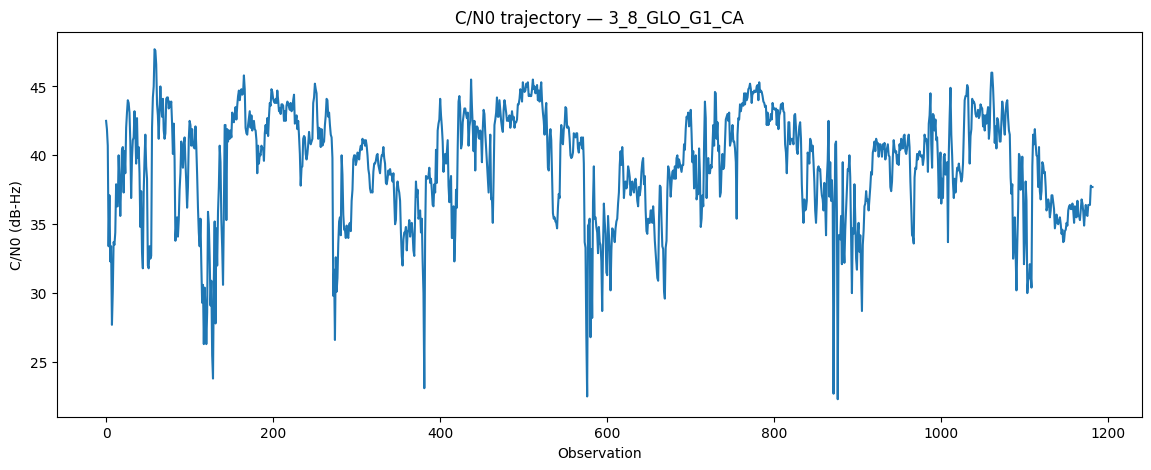

In [185]:
plt.figure(figsize=(14, 5))

plt.plot(
    signal_df.index,
    signal_df["Cn0DbHz"]
)

plt.xlabel("Observation")
plt.ylabel("C/N0 (dB-Hz)")
plt.title(f"C/N0 trajectory — {signal_id}")

plt.show()

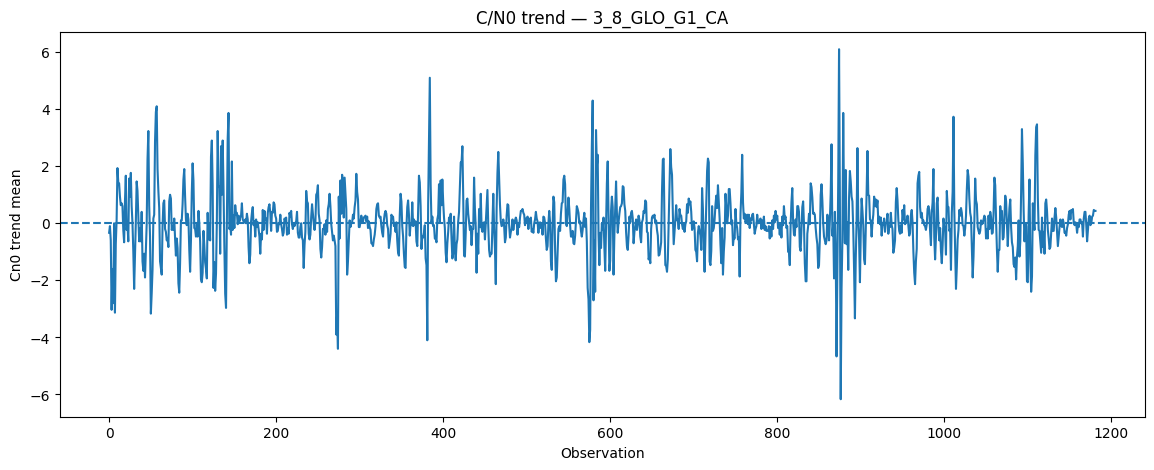

In [186]:
plt.figure(figsize=(14, 5))

plt.plot(
    signal_df.index,
    signal_df["Cn0_trend_mean"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Observation")
plt.ylabel("Cn0 trend mean")
plt.title(f"C/N0 trend — {signal_id}")

plt.show()

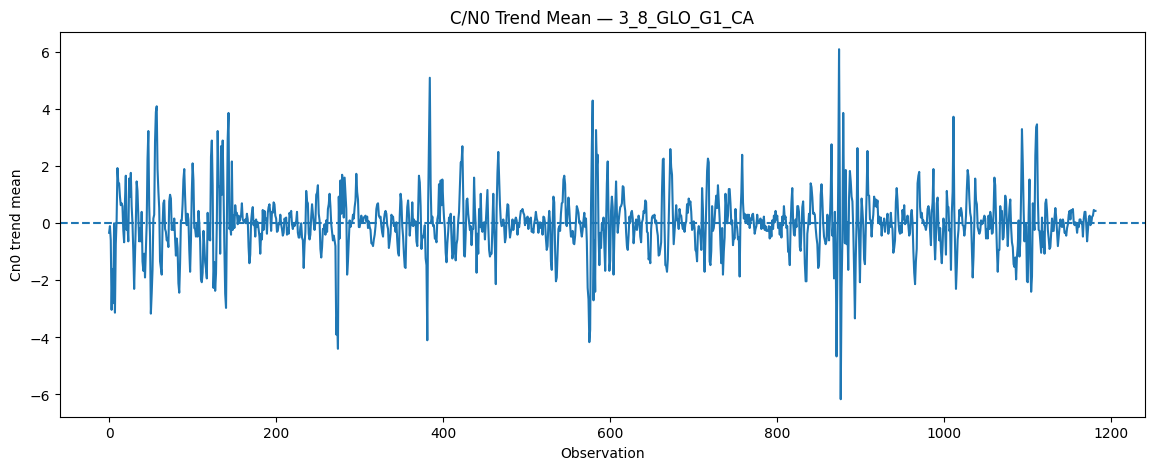

In [187]:
plt.figure(figsize=(14, 5))

plt.plot(
    signal_df.index,
    signal_df["Cn0_trend_mean"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Observation")
plt.ylabel("Cn0 trend mean")
plt.title(f"C/N0 Trend Mean — {signal_id}")

plt.show()

In [188]:


signal_df = signal_df.copy()

# Try a candidate meaningful trend threshold
threshold = 0.25

signal_df["strong_down"] = (
    signal_df["Cn0_trend_mean"] <= -threshold
)

signal_df["strong_up"] = (
    signal_df["Cn0_trend_mean"] >= threshold
)

# Find lengths of consecutive TRUE runs
def run_lengths(series):
    groups = (
        series != series.shift()
    ).cumsum()

    return series.groupby(groups).sum()

down_runs = run_lengths(signal_df["strong_down"])
up_runs = run_lengths(signal_df["strong_up"])

down_runs = down_runs[down_runs > 0]
up_runs = up_runs[up_runs > 0]

print("Strong DOWN episodes:")
print(down_runs.describe())

print("\nStrong UP episodes:")
print(up_runs.describe())

Strong DOWN episodes:
count    162.000000
mean       2.438272
std        1.544139
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: strong_down, dtype: float64

Strong UP episodes:
count    158.000000
mean       2.493671
std        1.571023
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: strong_up, dtype: float64


In [189]:
corrected_dir = Path("/content/gnss_features_v2")

train_files = [
    corrected_dir / f"gnss_{i:03d}.parquet"
    for i in range(1, 138)
]

print("Training files:", len(train_files))
print("First:", train_files[0])
print("Last:", train_files[-1])

Training files: 137
First: /content/gnss_features_v2/gnss_001.parquet
Last: /content/gnss_features_v2/gnss_137.parquet


In [190]:
path = train_files[0]

df = pd.read_parquet(
    path,
    columns=["signal_id", "Cn0_trend_mean"]
)

threshold = 0.25

all_down_runs = []
all_up_runs = []

for signal_id, group in df.groupby("signal_id"):

    values = group["Cn0_trend_mean"].to_numpy()

    strong_down = values <= -threshold
    strong_up = values >= threshold

    # DOWN runs
    down_groups = (
        pd.Series(strong_down)
        .ne(pd.Series(strong_down).shift())
        .cumsum()
    )

    down_lengths = (
        pd.Series(strong_down)
        .groupby(down_groups)
        .sum()
    )

    all_down_runs.extend(
        down_lengths[down_lengths > 0].astype(int).tolist()
    )

    # UP runs
    up_groups = (
        pd.Series(strong_up)
        .ne(pd.Series(strong_up).shift())
        .cumsum()
    )

    up_lengths = (
        pd.Series(strong_up)
        .groupby(up_groups)
        .sum()
    )

    all_up_runs.extend(
        up_lengths[up_lengths > 0].astype(int).tolist()
    )

print("File:", path.name)

print("\nStrong DOWN episodes:")
print(pd.Series(all_down_runs).describe())

print("\nStrong UP episodes:")
print(pd.Series(all_up_runs).describe())

File: gnss_001.parquet

Strong DOWN episodes:
count    6391.000000
mean        2.418557
std         1.604247
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        12.000000
dtype: float64

Strong UP episodes:
count    6288.000000
mean        2.452290
std         1.661783
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        18.000000
dtype: float64


In [191]:

threshold = 0.25

all_down_runs = []
all_up_runs = []

for i in range(1, 138):

    path = corrected_dir / f"gnss_{i:03d}.parquet"

    df = pd.read_parquet(
        path,
        columns=["signal_id", "Cn0_trend_mean"]
    )

    for signal_id, group in df.groupby("signal_id"):

        values = group["Cn0_trend_mean"].to_numpy()

        strong_down = values <= -threshold
        strong_up = values >= threshold

        # -----------------------------
        # DOWN EPISODES
        # -----------------------------
        down_groups = (
            pd.Series(strong_down)
            .ne(pd.Series(strong_down).shift())
            .cumsum()
        )

        down_lengths = (
            pd.Series(strong_down)
            .groupby(down_groups)
            .sum()
        )

        all_down_runs.extend(
            down_lengths[down_lengths > 0]
            .astype(int)
            .tolist()
        )

        # -----------------------------
        # UP EPISODES
        # -----------------------------
        up_groups = (
            pd.Series(strong_up)
            .ne(pd.Series(strong_up).shift())
            .cumsum()
        )

        up_lengths = (
            pd.Series(strong_up)
            .groupby(up_groups)
            .sum()
        )

        all_up_runs.extend(
            up_lengths[up_lengths > 0]
            .astype(int)
            .tolist()
        )

    if i % 10 == 0 or i == 137:
        print(f"[{i}/137] processed")

# Convert to Series
down_series = pd.Series(all_down_runs)
up_series = pd.Series(all_up_runs)


print("ALL TRAINING FILES — PERSISTENCE")
print("Threshold:", threshold)

print("\nStrong DOWN episodes:")
display(
    down_series.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print("\nStrong UP episodes:")
display(
    up_series.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

[10/137] processed
[20/137] processed
[30/137] processed
[40/137] processed
[50/137] processed
[60/137] processed
[70/137] processed
[80/137] processed
[90/137] processed
[100/137] processed
[110/137] processed
[120/137] processed
[130/137] processed
[137/137] processed
ALL TRAINING FILES — PERSISTENCE
Threshold: 0.25

Strong DOWN episodes:


,0
count,950547.000000
mean,2.534447
std,1.782978
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,5.000000
95%,6.000000
max,32.000000



Strong UP episodes:


,0
count,950388.000000
mean,2.490143
std,1.677230
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,5.000000
95%,6.000000
max,22.000000


In [192]:

persistence_options = [2, 3, 5]

print("STRONG DOWN EPISODES")


for n in persistence_options:
    count = (down_series >= n).sum()
    percentage = (count / len(down_series)) * 100

    print(
        f"{n} consecutive observations: "
        f"{count:,} episodes ({percentage:.2f}%)"
    )

print("nSTRONG UP EPISODES")
print("-----")

for n in persistence_options:
    count = (up_series >= n).sum()
    percentage = (count / len(up_series)) * 100

    print(
        f"{n} consecutive observations: "
        f"{count:,} episodes ({percentage:.2f}%)"
    )

STRONG DOWN EPISODES
--------------------
2 consecutive observations: 592,155 episodes (62.30%)
3 consecutive observations: 408,075 episodes (42.93%)
5 consecutive observations: 112,307 episodes (11.81%)
nSTRONG UP EPISODES
------------------
2 consecutive observations: 593,896 episodes (62.49%)
3 consecutive observations: 410,249 episodes (43.17%)
5 consecutive observations: 102,838 episodes (10.82%)


In [195]:
strength_thresholds = [30, 32, 35]

print("WEAK STRENGTH COVERAGE")

for threshold in strength_thresholds:
    weak_count = (cn0_series < threshold).sum()
    percentage = (weak_count / len(cn0_series)) * 100

    print(
        f"C/N0 < {threshold}: "
        f"{weak_count:,} observations "
        f"({percentage:.2f}%)"
    )

WEAK STRENGTH COVERAGE
----------------------
C/N0 < 30: 9,052 observations (20.54%)
C/N0 < 32: 13,136 observations (29.81%)
C/N0 < 35: 20,090 observations (45.60%)


In [196]:
healthy_thresholds = [35, 37, 40]

print("HEALTHY STRENGTH COVERAGE")

for threshold in healthy_thresholds:
    healthy_count = (cn0_series >= threshold).sum()
    percentage = (healthy_count / len(cn0_series)) * 100

    print(
        f"C/N0 >= {threshold}: "
        f"{healthy_count:,} observations "
        f"({percentage:.2f}%)"
    )

HEALTHY STRENGTH COVERAGE
C/N0 >= 35: 23,971 observations (54.40%)
C/N0 >= 37: 18,325 observations (41.59%)
C/N0 >= 40: 10,084 observations (22.89%)


In [197]:
signal_id = "3_8_GLO_G1_CA"

signal = (
    df[df["signal_id"] == signal_id]
    .sort_values("utcTimeMillis")
    .reset_index(drop=True)
)

print("Observations:", len(signal))

cols = [
    "utcTimeMillis",
    "Cn0DbHz",
    "Cn0_trend_mean",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_range_5",
    "up_streak",
    "down_streak"
]

display(signal[cols].head(30))

Observations: 1182


,utcTimeMillis,Cn0DbHz,Cn0_trend_mean,Cn0_slope,Cn0_acceleration,Cn0_range_5,up_streak,down_streak
0,1607715060442,42.5,-0.333333,0.150,-0.550,1.6,0,1
1,1607715061442,41.9,-0.100000,-0.400,-0.550,1.6,0,2
2,1607715062442,40.7,-0.600000,-0.375,0.025,1.8,0,3
3,1607715063442,33.4,-3.033333,-2.275,-1.900,9.1,0,4
4,1607715064442,37.1,-1.600000,-1.350,0.925,9.1,0,5
5,1607715065442,32.3,-2.800000,-2.400,-1.050,9.6,0,6
6,1607715066442,33.4,0.000000,-1.825,0.575,8.4,0,0
7,1607715067442,27.7,-3.133333,-1.425,0.400,9.4,0,1
8,1607715068442,30.1,-0.733333,-1.750,-0.325,9.4,0,2
9,1607715069442,33.7,0.100000,0.350,2.100,6.0,1,0


In [199]:
file_path = "/content/gnss_features_v2/gnss_001.parquet"

In [198]:
weak_threshold = 30
healthy_threshold = 37
persistence = 3

conditions = {
    "WEAK + STRONG DOWN":
        (cn0_series < weak_threshold) & (down_series >= persistence),

    "WEAK + STRONG UP":
        (cn0_series < weak_threshold) & (up_series >= persistence),

    "HEALTHY + STRONG DOWN":
        (cn0_series >= healthy_threshold) & (down_series >= persistence),

    "HEALTHY + STRONG UP":
        (cn0_series >= healthy_threshold) & (up_series >= persistence),
}

print("STRENGTH + TREND COMBINATIONS")

for name, condition in conditions.items():
    count = condition.sum()
    percentage = (count / len(cn0_series)) * 100

    print(f"{name}: {count:,} ({percentage:.2f}%)")

STRENGTH + TREND COMBINATIONS
WEAK + STRONG DOWN: 3,874 (8.79%)
WEAK + STRONG UP: 3,918 (8.89%)
HEALTHY + STRONG DOWN: 7,643 (17.35%)
HEALTHY + STRONG UP: 7,630 (17.32%)


In [200]:
import pandas as pd
import os

weak_threshold = 30
healthy_threshold = 37
persistence = 3

total = 0
counts = {
    "WEAK + STRONG DOWN": 0,
    "WEAK + STRONG UP": 0,
    "HEALTHY + STRONG DOWN": 0,
    "HEALTHY + STRONG UP": 0,
}

for i in range(1, 138):

    file_path = f"/content/gnss_features_v2/gnss_{i:03d}.parquet"

    data = pd.read_parquet(
        file_path,
        columns=["Cn0DbHz", "up_streak", "down_streak"]
    )

    total += len(data)

    counts["WEAK + STRONG DOWN"] += (
        (data["Cn0DbHz"] < weak_threshold) &
        (data["down_streak"] >= persistence)
    ).sum()

    counts["WEAK + STRONG UP"] += (
        (data["Cn0DbHz"] < weak_threshold) &
        (data["up_streak"] >= persistence)
    ).sum()

    counts["HEALTHY + STRONG DOWN"] += (
        (data["Cn0DbHz"] >= healthy_threshold) &
        (data["down_streak"] >= persistence)
    ).sum()

    counts["HEALTHY + STRONG UP"] += (
        (data["Cn0DbHz"] >= healthy_threshold) &
        (data["up_streak"] >= persistence)
    ).sum()

print("TRAINING SET: gnss_001 → gnss_137")
print(f"Total observations: {total:,}\n")

for name, count in counts.items():
    percentage = (count / total) * 100
    print(f"{name}: {count:,} ({percentage:.2f}%)")

TRAINING SET: gnss_001 → gnss_137
Total observations: 7,684,416

WEAK + STRONG DOWN: 717,690 (9.34%)
WEAK + STRONG UP: 324,646 (4.22%)
HEALTHY + STRONG DOWN: 408,344 (5.31%)
HEALTHY + STRONG UP: 670,679 (8.73%)


In [202]:
import pandas as pd

recovery_persistence_options = [3, 5, 7]

recovery_counts = {
    n: 0 for n in recovery_persistence_options
}

total_observations = 0

for i in range(1, 138):

    file_path = f"/content/gnss_features_v2/gnss_{i:03d}.parquet"

    data = pd.read_parquet(
        file_path,
        columns=[
            "Cn0DbHz",
            "up_streak"
        ]
    )

    total_observations += len(data)

    weak = data["Cn0DbHz"] < 30

    for n in recovery_persistence_options:
        recovery_counts[n] += (
            weak &
            (data["up_streak"] >= n)
        ).sum()

print("WEAK + PERSISTENT UP")

for n in recovery_persistence_options:
    count = recovery_counts[n]
    percentage = (count / total_observations) * 100

    print(
        f"{n} consecutive UP observations: "
        f"{count:,} ({percentage:.2f}%)"
    )

WEAK + PERSISTENT UP
--------------------
3 consecutive UP observations: 324,646 (4.22%)
5 consecutive UP observations: 88,164 (1.15%)
7 consecutive UP observations: 25,863 (0.34%)


In [203]:
import pandas as pd

WEAK_THRESHOLD = 30
HEALTHY_THRESHOLD = 37
DOWN_PERSISTENCE = 3
UP_PERSISTENCE = 3

state_counts = {
    "GOOD": 0,
    "DEGRADING": 0,
    "BAD": 0,
    "RECOVERY": 0
}

total_observations = 0


def assign_states(data):
    data = data.sort_values(
        ["signal_id", "utcTimeMillis"]
    ).copy()

    states = []

    for signal_id, signal_df in data.groupby("signal_id", sort=False):

        current_state = "GOOD"

        for _, row in signal_df.iterrows():

            cn0 = row["Cn0DbHz"]
            up = row["up_streak"]
            down = row["down_streak"]

            healthy = cn0 >= HEALTHY_THRESHOLD
            weak = cn0 < WEAK_THRESHOLD

            strong_up = up >= UP_PERSISTENCE
            strong_down = down >= DOWN_PERSISTENCE

            if current_state == "GOOD":

                if healthy and strong_down:
                    current_state = "DEGRADING"

            elif current_state == "DEGRADING":

                if weak and strong_down:
                    current_state = "BAD"

                elif strong_up and healthy:
                    current_state = "GOOD"

            elif current_state == "BAD":

                if strong_up:
                    current_state = "RECOVERY"

            elif current_state == "RECOVERY":

                if healthy and strong_up:
                    current_state = "GOOD"

                elif strong_down:
                    current_state = "BAD"

            states.append((signal_id, row.name, current_state))

    return states


for i in range(1, 138):

    file_path = f"/content/gnss_features_v2/gnss_{i:03d}.parquet"

    data = pd.read_parquet(
        file_path,
        columns=[
            "signal_id",
            "utcTimeMillis",
            "Cn0DbHz",
            "up_streak",
            "down_streak"
        ]
    )

    states = assign_states(data)

    for _, _, state in states:
        state_counts[state] += 1

    total_observations += len(data)

    if i % 20 == 0:
        print(f"Processed {i}/137 files...")

print("\nTRAINING STATE DISTRIBUTION")

for state, count in state_counts.items():

    percentage = (count / total_observations) * 100

    print(
        f"{state}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )

print(f"\nTotal observations: {total_observations:,}")

Processed 20/137 files...
Processed 40/137 files...
Processed 60/137 files...
Processed 80/137 files...
Processed 100/137 files...
Processed 120/137 files...

TRAINING STATE DISTRIBUTION
GOOD: 5,639,776 (73.39%)
DEGRADING: 1,282,552 (16.69%)
BAD: 400,993 (5.22%)
RECOVERY: 361,095 (4.70%)

Total observations: 7,684,416


In [204]:
import pandas as pd

WEAK_THRESHOLD = 30
HEALTHY_THRESHOLD = 37
DOWN_PERSISTENCE = 3
UP_PERSISTENCE = 3

state_counts = {
    "GOOD": 0,
    "DEGRADING": 0,
    "BAD": 0,
    "RECOVERY": 0
}

total_observations = 0


def assign_states(data):
    data = data.sort_values(
        ["signal_id", "utcTimeMillis"]
    ).copy()

    states = []

    for signal_id, signal_df in data.groupby("signal_id", sort=False):

        current_state = "GOOD"

        for _, row in signal_df.iterrows():

            cn0 = row["Cn0DbHz"]
            up = row["up_streak"]
            down = row["down_streak"]

            healthy = cn0 >= HEALTHY_THRESHOLD
            weak = cn0 < WEAK_THRESHOLD

            strong_up = up >= UP_PERSISTENCE
            strong_down = down >= DOWN_PERSISTENCE

            if current_state == "GOOD":

                if healthy and strong_down:
                    current_state = "DEGRADING"

            elif current_state == "DEGRADING":

                if weak and strong_down:
                    current_state = "BAD"

                elif strong_up and healthy:
                    current_state = "GOOD"

            elif current_state == "BAD":

                if strong_up:
                    current_state = "RECOVERY"

            elif current_state == "RECOVERY":

                if healthy and strong_up:
                    current_state = "GOOD"

                elif strong_down:
                    current_state = "BAD"

            states.append((signal_id, row.name, current_state))

    return states


for i in range(138, 166):

    file_path = f"/content/gnss_features_v2/gnss_{i:03d}.parquet"

    data = pd.read_parquet(
        file_path,
        columns=[
            "signal_id",
            "utcTimeMillis",
            "Cn0DbHz",
            "up_streak",
            "down_streak"
        ]
    )

    states = assign_states(data)

    for _, _, state in states:
        state_counts[state] += 1

    total_observations += len(data)

    if i % 20 == 0:
        print(f"Processed {i}/137 files...")

print("\nTRAINING STATE DISTRIBUTION")

for state, count in state_counts.items():

    percentage = (count / total_observations) * 100

    print(
        f"{state}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )

print(f"\nTotal observations: {total_observations:,}")

Processed 140/137 files...
Processed 160/137 files...

TRAINING STATE DISTRIBUTION
GOOD: 834,404 (66.04%)
DEGRADING: 295,596 (23.39%)
BAD: 76,313 (6.04%)
RECOVERY: 57,254 (4.53%)

Total observations: 1,263,567


In [206]:
import pandas as pd
import os

WEAK_THRESHOLD = 30
HEALTHY_THRESHOLD = 37
DOWN_PERSISTENCE = 3
UP_PERSISTENCE = 3


def label_signal(signal_df):
    signal_df = signal_df.sort_values("utcTimeMillis").copy()

    current_state = "GOOD"
    states = []

    for _, row in signal_df.iterrows():

        cn0 = row["Cn0DbHz"]
        up = row["up_streak"]
        down = row["down_streak"]

        weak = cn0 < WEAK_THRESHOLD
        healthy = cn0 >= HEALTHY_THRESHOLD

        strong_up = up >= UP_PERSISTENCE
        strong_down = down >= DOWN_PERSISTENCE

        if current_state == "GOOD":

            if healthy and strong_down:
                current_state = "DEGRADING"

        elif current_state == "DEGRADING":

            if weak and strong_down:
                current_state = "BAD"

            elif strong_up and healthy:
                current_state = "GOOD"

        elif current_state == "BAD":

            if strong_up:
                current_state = "RECOVERY"

        elif current_state == "RECOVERY":

            if healthy and strong_up:
                current_state = "GOOD"

            elif strong_down:
                current_state = "BAD"

        states.append(current_state)

    signal_df["state"] = states

    return signal_df


# Test on one file first
file_path = "/content/gnss_features_v2/gnss_001.parquet"

df_test = pd.read_parquet(file_path)

labeled_parts = []

for signal_id, signal_df in df_test.groupby("signal_id", sort=False):
    labeled_parts.append(label_signal(signal_df))

df_labeled = pd.concat(labeled_parts).sort_index()

# Save test result separately first
test_output = "/content/gnss_features_v2/gnss_001_labeled.parquet"

df_labeled.to_parquet(
    test_output,
    index=False
)

print("Saved:", test_output)
print("\nState distribution:")
print(df_labeled["state"].value_counts())

print("\nColumns containing state:", "state" in df_labeled.columns)

Saved: /content/gnss_features_v2/gnss_001_labeled.parquet

State distribution:
state
GOOD         31435
DEGRADING     8906
BAD           2046
RECOVERY      1674
Name: count, dtype: int64

Columns containing state: True


In [207]:
import pandas as pd
import os

INPUT_DIR = "/content/gnss_features_v2"
OUTPUT_DIR = "/content/gnss_labeled_v2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

WEAK_THRESHOLD = 30
HEALTHY_THRESHOLD = 37
DOWN_PERSISTENCE = 3
UP_PERSISTENCE = 3


def label_signal(signal_df):
    signal_df = signal_df.sort_values("utcTimeMillis").copy()

    current_state = "GOOD"
    states = []

    for _, row in signal_df.iterrows():

        cn0 = row["Cn0DbHz"]
        up = row["up_streak"]
        down = row["down_streak"]

        weak = cn0 < WEAK_THRESHOLD
        healthy = cn0 >= HEALTHY_THRESHOLD

        strong_up = up >= UP_PERSISTENCE
        strong_down = down >= DOWN_PERSISTENCE

        if current_state == "GOOD":

            if healthy and strong_down:
                current_state = "DEGRADING"

        elif current_state == "DEGRADING":

            if weak and strong_down:
                current_state = "BAD"

            elif strong_up and healthy:
                current_state = "GOOD"

        elif current_state == "BAD":

            if strong_up:
                current_state = "RECOVERY"

        elif current_state == "RECOVERY":

            if healthy and strong_up:
                current_state = "GOOD"

            elif strong_down:
                current_state = "BAD"

        states.append(current_state)

    signal_df["state"] = states

    return signal_df


for i in range(1, 197):

    filename = f"gnss_{i:03d}.parquet"

    input_path = os.path.join(INPUT_DIR, filename)
    output_path = os.path.join(OUTPUT_DIR, filename)

    data = pd.read_parquet(input_path)

    labeled_parts = []

    for signal_id, signal_df in data.groupby("signal_id", sort=False):
        labeled_parts.append(label_signal(signal_df))

    labeled_data = pd.concat(
        labeled_parts,
        ignore_index=True
    )

    labeled_data.to_parquet(
        output_path,
        index=False
    )

    if i % 20 == 0 or i == 196:
        print(f"Processed {i}/196 files")

print("Output directory:", OUTPUT_DIR)

Processed 20/196 files
Processed 40/196 files
Processed 60/196 files
Processed 80/196 files
Processed 100/196 files
Processed 120/196 files
Processed 140/196 files
Processed 160/196 files
Processed 180/196 files
Processed 196/196 files
Output directory: /content/gnss_labeled_v2


In [208]:

OUTPUT_DIR = "/content/gnss_labeled_v2"

files = sorted(
    f for f in os.listdir(OUTPUT_DIR)
    if f.endswith(".parquet")
)

print("Total files:", len(files))
print("First 3:", files[:3])
print("Last 3:", files[-3:])

# Check one file
sample = pd.read_parquet(
    os.path.join(OUTPUT_DIR, "gnss_001.parquet")
)

print("\nHas state:", "state" in sample.columns)
print("Number of columns:", len(sample.columns))

print("\nState distribution:")
print(sample["state"].value_counts())

Total files: 196
First 3: ['gnss_001.parquet', 'gnss_002.parquet', 'gnss_003.parquet']
Last 3: ['gnss_194.parquet', 'gnss_195.parquet', 'gnss_196.parquet']

Has state: True
Number of columns: 33

State distribution:
state
GOOD         31435
DEGRADING     8906
BAD           2046
RECOVERY      1674
Name: count, dtype: int64


In [209]:
input_features = [
    "Cn0DbHz",
    "Cn0_change",
    "Cn0_trend",
    "Cn0_trend_mean",
    "down_streak",
    "up_streak",
    "PseudorangeRateMetersPerSecond",
    "PseudorangeRate_change",
    "SvElevationDegrees",
    "Elevation_change",
    "SvAzimuthDegrees",
    "Azimuth_change",
    "Cn0_rolling_std",
    "Cn0_slope",
    "Cn0_acceleration",
    "Cn0_min_5",
    "Cn0_max_5",
    "Cn0_range_5",
    "negative_change_count_10",
    "positive_change_count_10"
]

target = "state"

missing = [
    col for col in input_features + [target]
    if col not in sample.columns
]

print("Number of input features:", len(input_features))
print("Missing columns:", missing)
print("Target column:", target)

Number of input features: 20
Missing columns: []
Target column: state
